 * @ Author: Yohei Ohto
 * @ Create Time: 2025-04-25 12:43:24
 * @ Modified time: 2025-08-15 17:44:40

This notebook processes and analyzes chemical compound data from the SureChEMBL database. It performs the following tasks:

- Loads and preprocesses compound data, including SMILES strings and publication years.
- Computes molecular fingerprints (ECFP) and MinHash signatures for efficient similarity search.
- Constructs k-nearest neighbor graphs using locality-sensitive hashing (LSH) and tmap for large-scale visualization.
- Visualizes compound distributions and their temporal trends using custom color maps.
- Calculates homophily ratios and statistical significance (p-values) to assess clustering by publication year.
- Identifies and visualizes neighboring compounds for a given target molecule.
- Saves intermediate and final results for further analysis and reproducibility.

# make t-map in surechembl

In [2]:
import multiprocessing as mp
import os
import pickle
import random
import re
import sys

import numpy as np
import pandas as pd
import tmap
import tmap as tm
from faerun import Faerun
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors
from tqdm import tqdm
from tqdm.auto import trange

RDLogger.DisableLog('rdApp.*')

import collections
import os
import pickle
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2

current_dir = os.getcwd()
parent_parent_dir = os.path.dirname(os.path.dirname(current_dir))
src_dir = os.path.join(parent_parent_dir, 'src')
sys.path.append(src_dir)

from util import *
# from chemo_process import *

In [22]:
df = pd.read_csv("../../data/processed/surechembl/molecular_descriptors_with_date.csv")

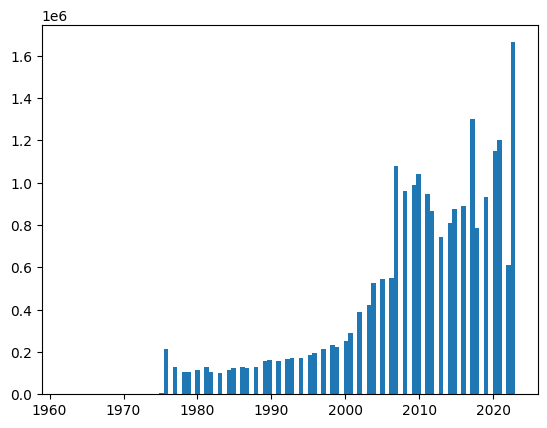

In [23]:
dates_all = [int(df["DATE"][i]) for i in range(len(df))]
plt.hist(dates_all, bins=100)
plt.show()

In [24]:
print(max(dates_all), min(dates_all), max(dates_all) - min(dates_all))

2023 1962 61


In [25]:
indices = [i for i in range(len(df))]
sample_size = 1000000

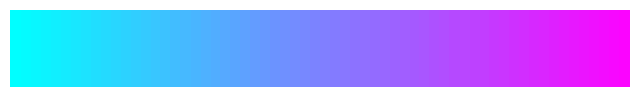

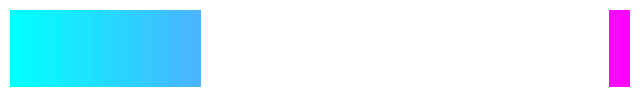

In [26]:
num_colors = min(dates_all)
total_colors = 2023 - num_colors + 1

base_cmap = plt.get_cmap("cool")
colors = [base_cmap(i / total_colors) for i in range(total_colors)]

black_section = [(0, 0, 0, 0)] * num_colors
new_colors = black_section + colors

colors_section = new_colors[num_colors:]

MY_CM = LinearSegmentedColormap.from_list("my_map_black", colors_section, N=len(colors_section))
MY_CM_FULL = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1))
plt.imshow(gradient, aspect="auto", cmap=MY_CM)
plt.axis("off")
plt.show()

for i in range(19, len(colors_section) - 2):
    colors_section[i] = (0, 0, 0, 0)

new_colors[num_colors:] = colors_section

MY_CM = LinearSegmentedColormap.from_list("my_map_black", colors_section, N=len(colors_section))
MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1))
plt.imshow(gradient, aspect="auto", cmap=MY_CM)
plt.axis("off")
plt.show()

In [27]:
scores = []
num_permutations = 1000

In [3]:
def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t]) 
    purity = np.sum(matches) / len(matches)
    return purity

In [29]:
for id in range(0, 10):
    if id == 0:
        start_time = time.time()

    random.seed(id)

    output_dir = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}"
    smiles_path = os.path.join(output_dir, "smiles.pkl")
    years_path = os.path.join(output_dir, "years.pkl")
    ecfps_path = os.path.join(output_dir, "ecfps.pkl")

    if os.path.exists(smiles_path) and os.path.exists(years_path) and os.path.exists(ecfps_path):
        smiles = pickle_load(smiles_path)
        years = pickle_load(years_path)
        ecfps = pickle_load(ecfps_path)
    else:
        os.makedirs(output_dir, exist_ok=True)
        random.seed(id)

        sample_indices = random.sample(indices, sample_size)
        smiles, years, ecfps = [], [], []

        for i in sample_indices:
            s = df.iloc[i, 0]
            y = int(df.iloc[i, 1])
            ecfp = compute_ecfp(s)
            if ecfp is not None:
                smiles.append(s)
                years.append(y)
                ecfps.append(ecfp)

        print(f"save: smiles({len(smiles)}), years({len(years)}), ecfps({len(ecfps)})")
        pickle_dump(smiles, smiles_path)
        pickle_dump(years, years_path)
        pickle_dump(ecfps, ecfps_path)

    if id == 0:
        elapsed_time = time.time() - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"loaded data for i=0: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

    filepaths = {
        "x": f"{output_dir}/x.pkl",
        "y": f"{output_dir}/y.pkl",
        "s": f"{output_dir}/s.pkl",
        "t": f"{output_dir}/t.pkl",
    }

    if all(os.path.exists(path) for path in filepaths.values()):
        print(f"ID {id}: skipping knn graph creation, files already exist.")
        x = pickle_load(filepaths["x"])
        y = pickle_load(filepaths["y"])
        s = pickle_load(filepaths["s"])
        t = pickle_load(filepaths["t"])
    else:
        enc = tm.Minhash(256)
        lf = tm.LSHForest(256)

        d, n = 2048, len(ecfps)
        data = [tm.VectorUchar(np.array(ecfps[x])) for x in trange(n)]
        
        lf.batch_add(enc.batch_from_binary_array(data))
        lf.index()

        knng_from, knng_to, knng_weight = tm.VectorUint(), tm.VectorUint(), tm.VectorFloat()
        _ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
        x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

        pickle_dump(list(x), filepaths["x"])
        pickle_dump(list(y), filepaths["y"])
        pickle_dump(list(s), filepaths["s"])
        pickle_dump(list(t), filepaths["t"])

    if id == 0:
        elapsed_time = time.time() - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"made knn graph for i=0: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

    labels_full = [year for year in years]
    labels_3 = [0 if year <= 1990 else 2 if year >= 2023 else 1 for year in years]
    labels_3, labels_full = np.array(labels_3), np.array(labels_full)

    output_plot = os.path.join(output_dir, f"surechembl_{id}.html")
    faerun = Faerun(clear_color="#111111", view="front", coords=False)
    faerun.add_scatter(
        f"surechembl_{id}",
        {"x": x, "y": y, "c": [labels_full, labels_full], "labels": smiles},
        colormap=[MY_CM_FULL, MY_CM_3],
        series_title=["Year", "Year_2"],
        shader="smoothCircle",
        point_scale=2.5,
        max_point_size=10,
        has_legend=True,
        categorical=True,
    )
    faerun.add_tree(
        f"surechembl_{id}_tree", {"from": s, "to": t}, point_helper=f"surechembl_{id}", color="#666666"
    )
    faerun.plot(output_plot, template="smiles")

    scores.append([id, lsh_forest_purity(s, t, labels_3), "3"])
    scores.append([id, lsh_forest_purity(s, t, labels_full), "full"])

    for labels, label_type in [(labels_3, "3"), (labels_full, "full")]:
        lsh_purity_real = lsh_forest_purity(s, t, labels)
        random_purities = []
        for _ in range(num_permutations):
            shuffled_labels = np.random.permutation(labels)
            random_purity = lsh_forest_purity(s, t, shuffled_labels)
            random_purities.append(random_purity)

        random_purities = np.array(random_purities)
        p_value = np.mean(random_purities >= lsh_purity_real)

        scores.append([id, p_value, label_type])
    hist_3_path = os.path.join(output_dir, "hist_3.png")
    hist_full_path = os.path.join(output_dir, "hist_full.png")

    plt.figure()
    plt.hist(labels_3, bins=3, color="blue", alpha=0.5)
    plt.title("Histogram of labels_3")
    plt.xlabel("Labels")
    plt.ylabel("Frequency")
    plt.savefig(hist_3_path)
    plt.close()

    plt.figure()
    plt.hist(labels_full, bins=43, color="red", alpha=0.5)
    plt.title("Histogram of labels_full")
    plt.xlabel("Labels")
    plt.ylabel("Frequency")
    plt.savefig(hist_full_path)
    plt.close()

    c = collections.Counter(labels_3)

    if id == 0:
        elapsed_time = time.time() - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Execution time for i=0: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

    print(f"Done {id}: {c}")

loaded data for i=0: 00:01:21
ID 0: skipping knn graph creation, files already exist.
made knn graph for i=0: 00:01:21


/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/0/surechembl_0.html.html

Execution time for i=0: 00:08:45
Done 0: Counter({np.int64(1): 843355, np.int64(0): 82711, np.int64(2): 70345})
ID 1: skipping knn graph creation, files already exist.


/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/1/surechembl_1.html.html

Done 1: Counter({np.int64(1): 843141, np.int64(0): 82648, np.int64(2): 70607})
ID 2: skipping knn graph creation, files already exist.


...

Done 7: Counter({np.int64(1): 843258, np.int64(0): 82523, np.int64(2): 70785})
ID 8: skipping knn graph creation, files already exist.


/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/8/surechembl_8.html.html

Done 8: Counter({np.int64(1): 843041, np.int64(0): 83110, np.int64(2): 70395})
ID 9: skipping knn graph creation, files already exist.


/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/9/surechembl_9.html.html

Done 9: Counter({np.int64(1): 843188, np.int64(0): 82536, np.int64(2): 70727})


# compute homophily ratio - vs random

  0%|          | 0/10 [00:00<?, ?it/s]

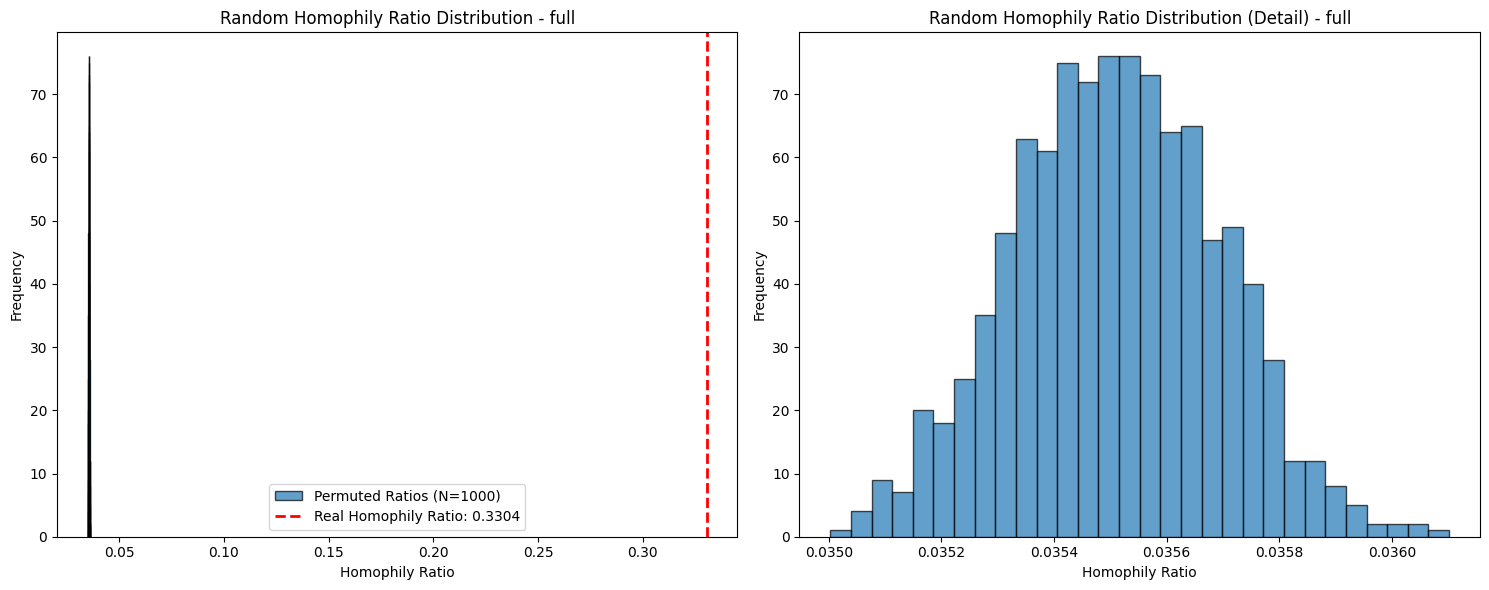

 10%|█         | 1/10 [03:28<31:17, 208.59s/it]

0 0.0 full
Done 0: Counter({np.int64(1): 843355, np.int64(0): 82711, np.int64(2): 70345})


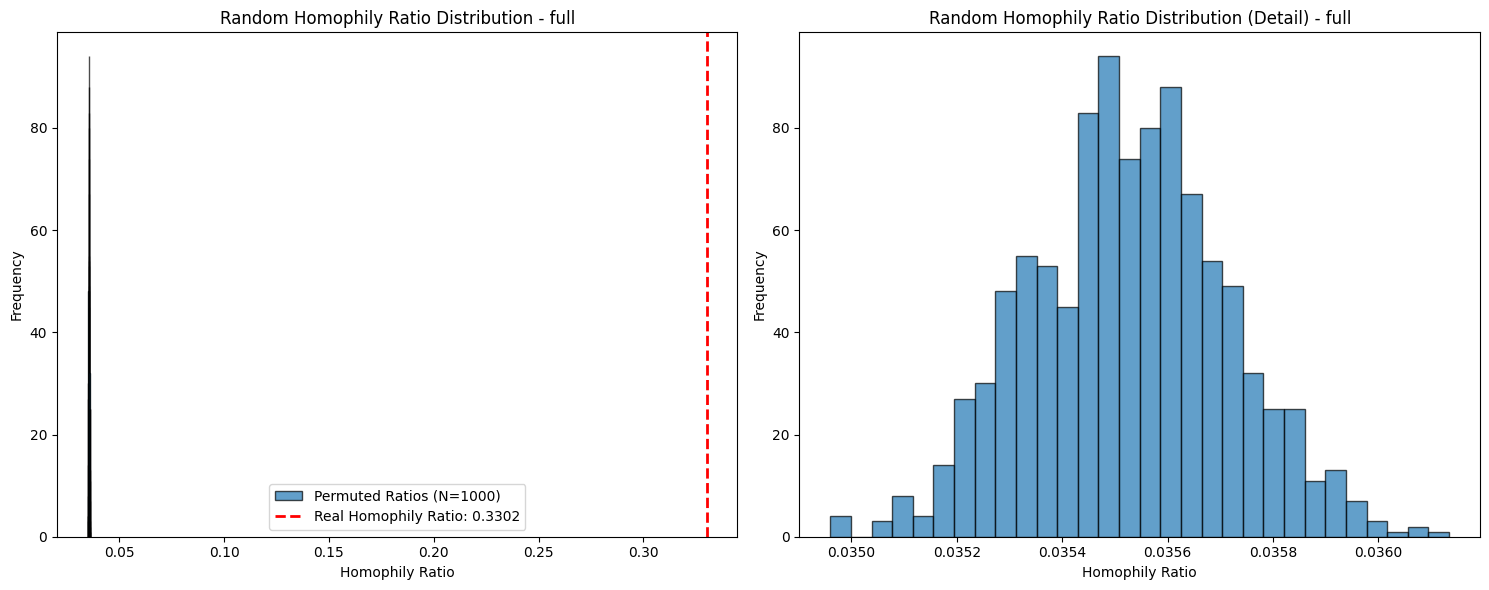

 20%|██        | 2/10 [06:52<27:27, 205.89s/it]

1 0.0 full
Done 1: Counter({np.int64(1): 843141, np.int64(0): 82648, np.int64(2): 70607})


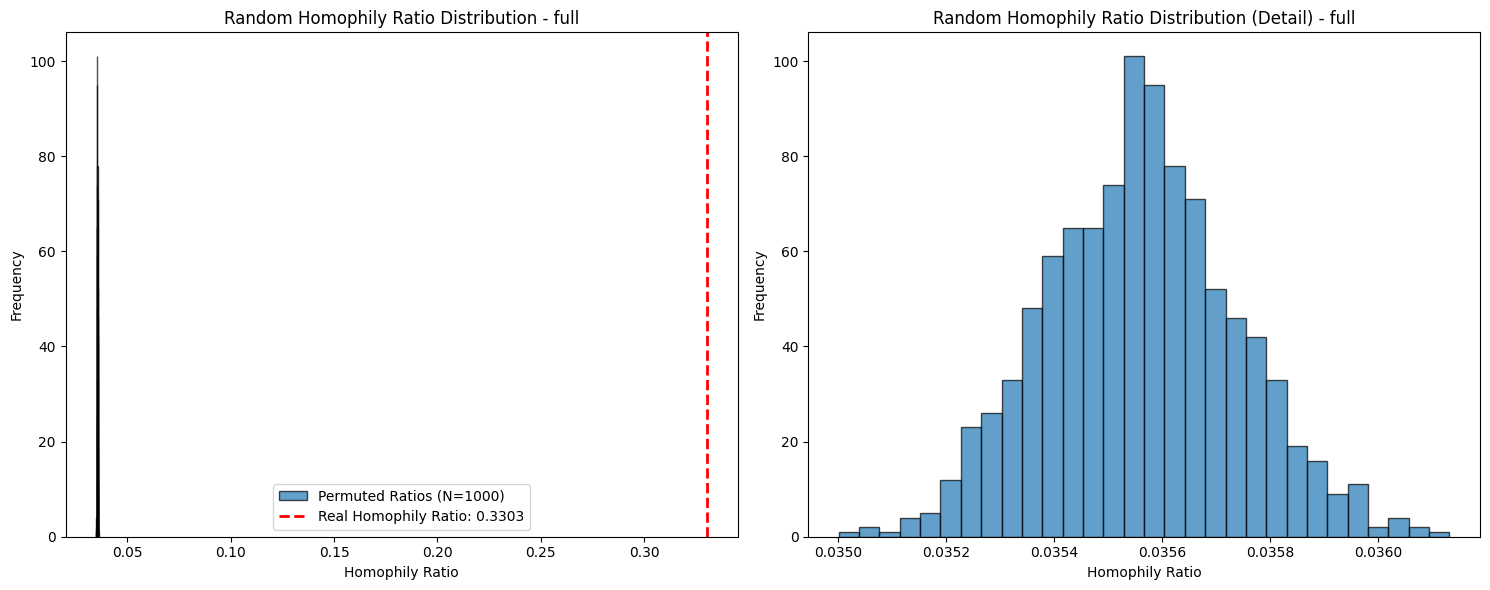

 30%|███       | 3/10 [10:03<23:12, 198.87s/it]

2 0.0 full
Done 2: Counter({np.int64(1): 843217, np.int64(0): 82542, np.int64(2): 70622})


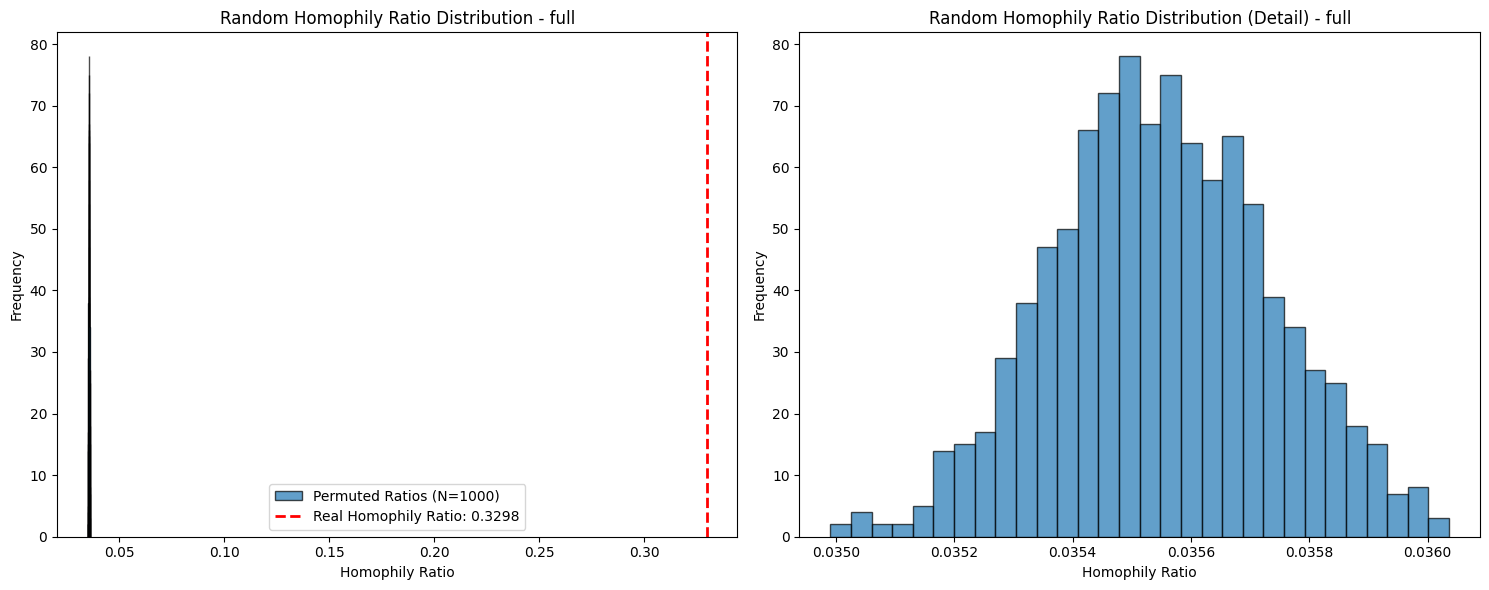

 40%|████      | 4/10 [13:20<19:49, 198.21s/it]

3 0.0 full
Done 3: Counter({np.int64(1): 843698, np.int64(0): 82652, np.int64(2): 70237})


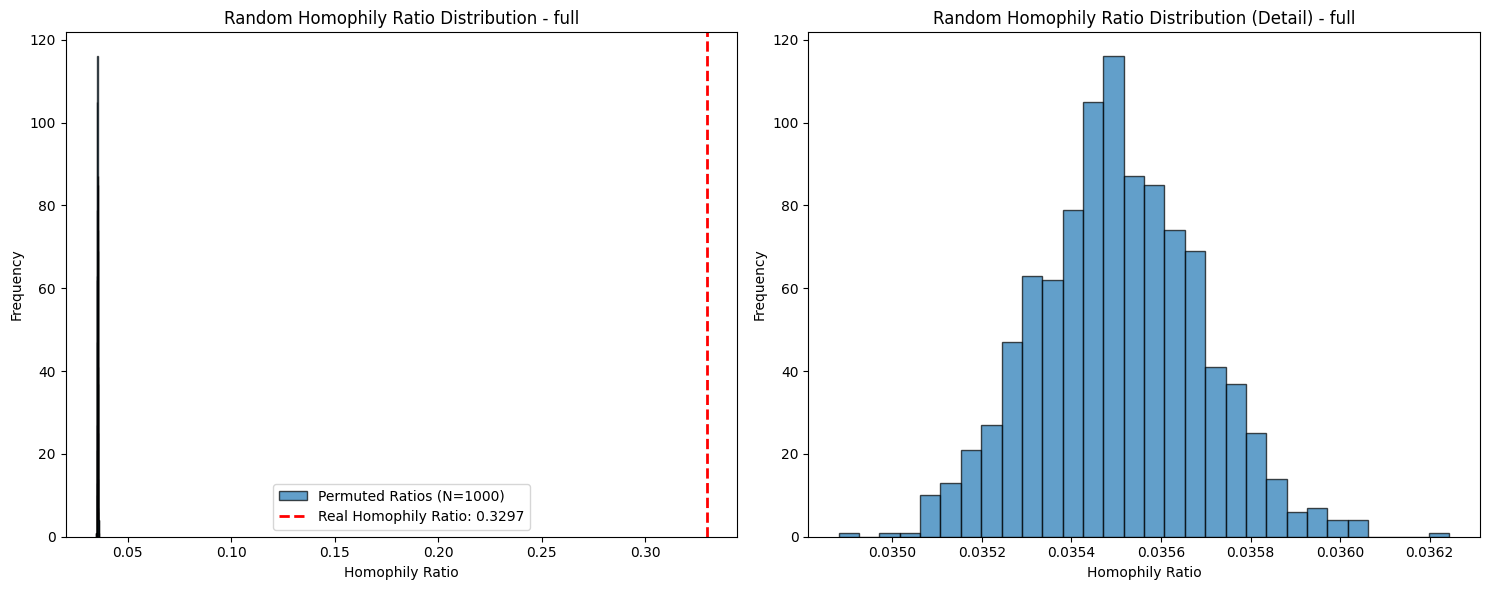

 50%|█████     | 5/10 [16:36<16:26, 197.37s/it]

4 0.0 full
Done 4: Counter({np.int64(1): 842946, np.int64(0): 83025, np.int64(2): 70470})


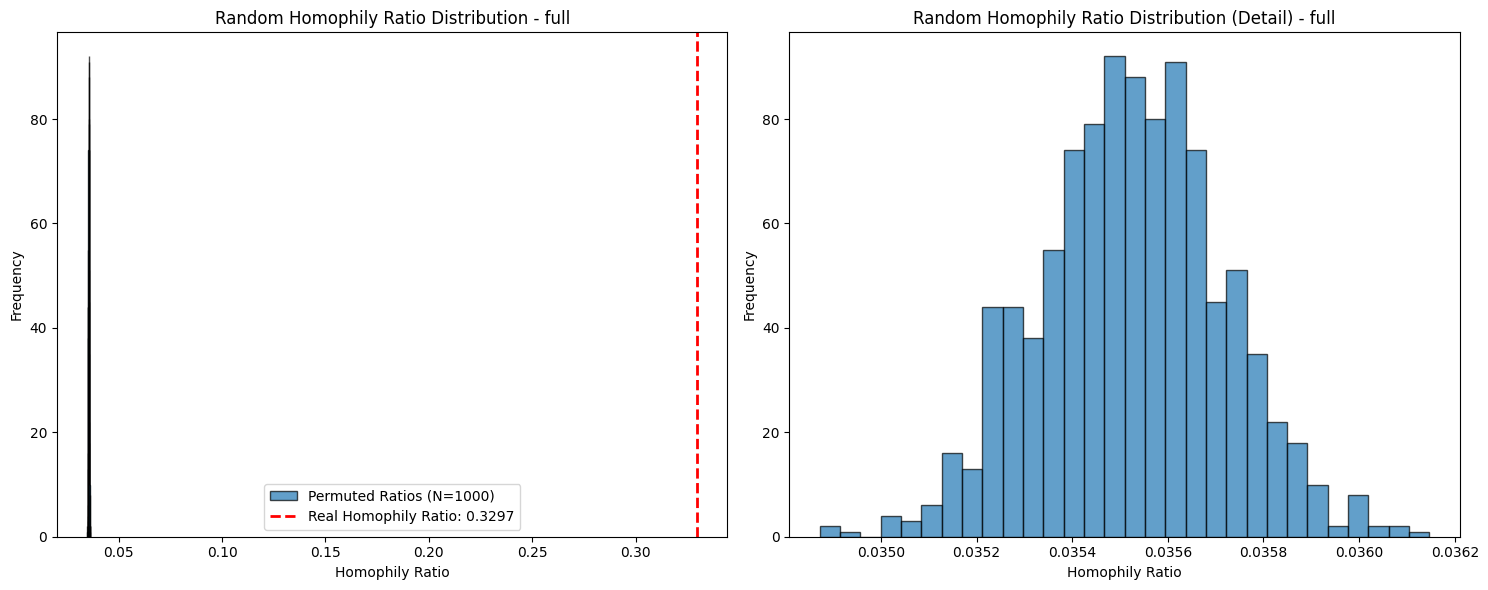

 60%|██████    | 6/10 [19:44<12:57, 194.32s/it]

5 0.0 full
Done 5: Counter({np.int64(1): 842949, np.int64(0): 82888, np.int64(2): 70602})


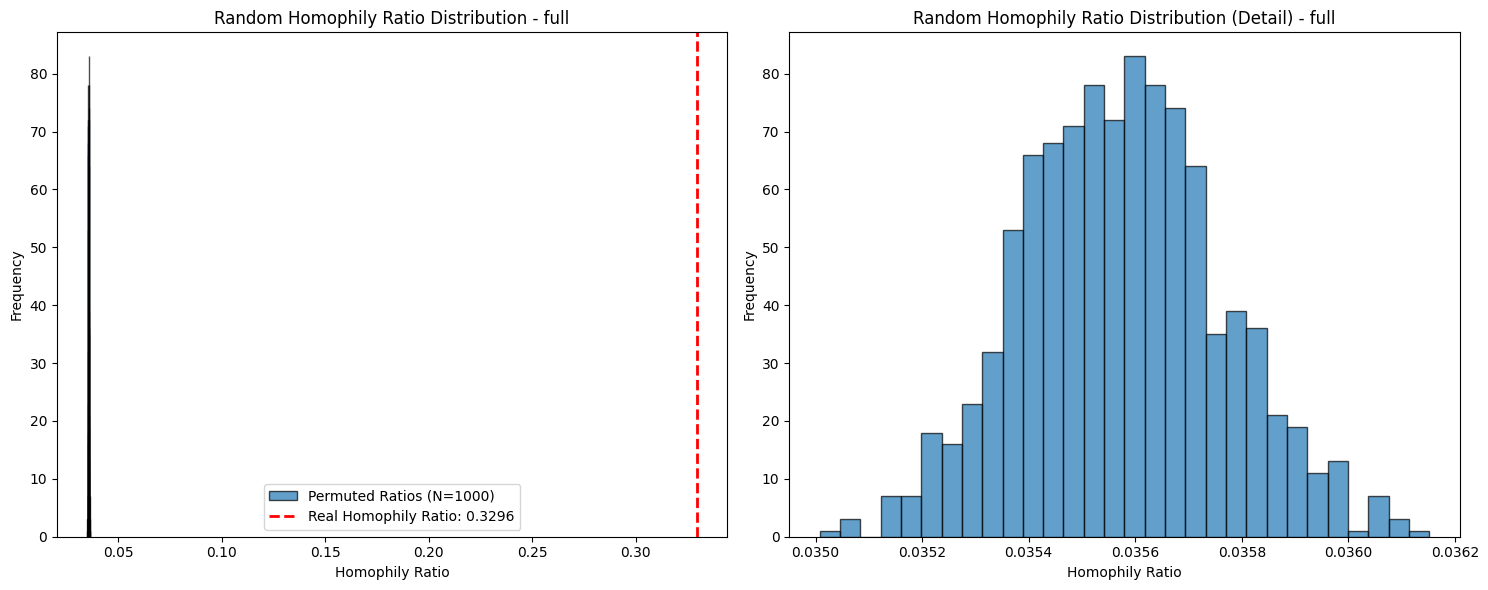

 70%|███████   | 7/10 [23:20<10:04, 201.41s/it]

6 0.0 full
Done 6: Counter({np.int64(1): 843139, np.int64(0): 82894, np.int64(2): 70492})


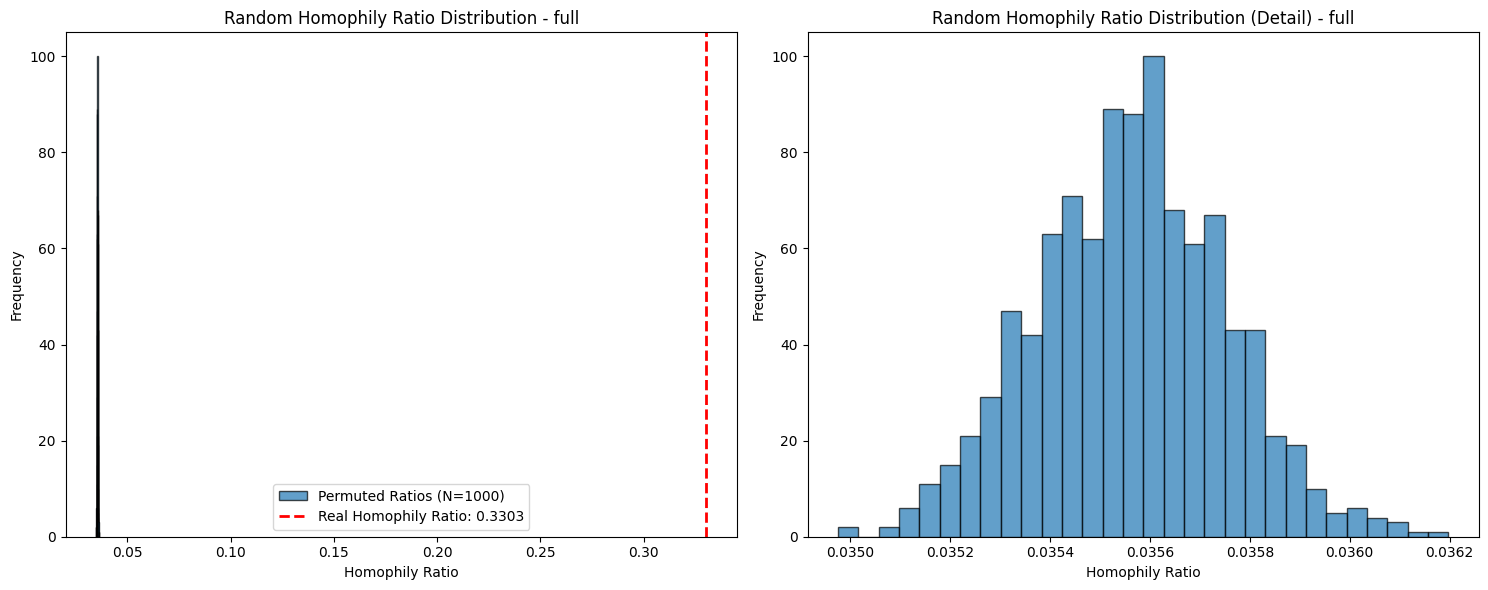

 80%|████████  | 8/10 [26:30<06:35, 197.64s/it]

7 0.0 full
Done 7: Counter({np.int64(1): 843258, np.int64(0): 82523, np.int64(2): 70785})


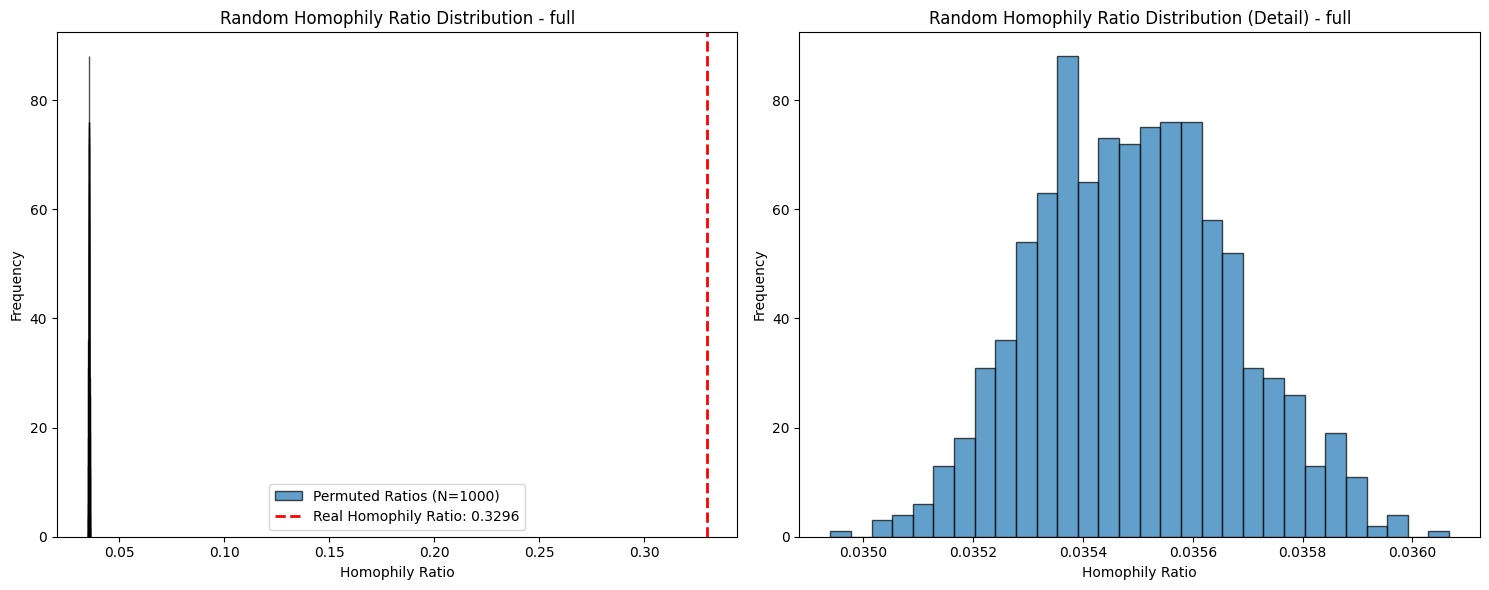

 90%|█████████ | 9/10 [29:41<03:15, 195.67s/it]

8 0.0 full
Done 8: Counter({np.int64(1): 843041, np.int64(0): 83110, np.int64(2): 70395})


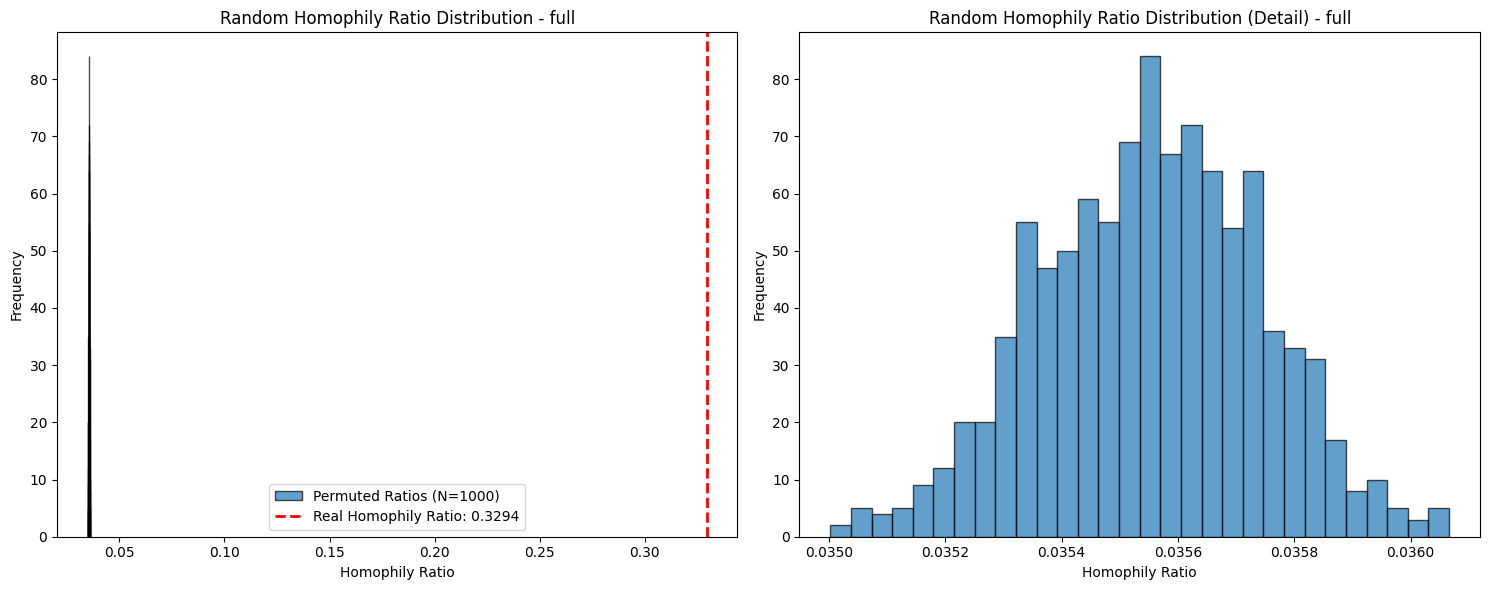

100%|██████████| 10/10 [32:48<00:00, 196.85s/it]

9 0.0 full
Done 9: Counter({np.int64(1): 843188, np.int64(0): 82536, np.int64(2): 70727})
統合p値 (labels_full): 0.00000e+00


In [ ]:
def compute_combined_pvalue(p_values):
    chi2_stat = -2 * np.sum(np.log(p_values))
    dof = 2 * len(p_values) 
    combined_p = chi2.sf(chi2_stat, dof)
    return combined_p

num_permutations = 1000
scores = []
p_values_3 = []
p_values_full = []

for id in trange(10):
    output_dir = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}"

    s_path = os.path.join(output_dir, "s.pkl")
    t_path = os.path.join(output_dir, "t.pkl")
    years_path = os.path.join(output_dir, "years.pkl")

    if not (os.path.exists(s_path) and os.path.exists(t_path) and os.path.exists(years_path)):
        print(f"Skipping ID {id}, required files missing.")
        continue

    s = pickle_load(s_path)
    t = pickle_load(t_path)
    years = pickle_load(years_path)
    labels_full = [year for year in years]
    labels_3 = [0 if year <= 1990 else 2 if year >= 2023 else 1 for year in years]
    labels_3, labels_full = np.array(labels_3), np.array(labels_full)

    for labels, label_type in [(labels_3, "3"), (labels_full, "full")]:
    # for labels, label_type in [(labels_full, "full")]:
        lsh_purity_real = lsh_forest_purity(s, t, labels)
        random_purities = []

        for _ in range(num_permutations):
            shuffled_labels = np.random.permutation(labels)
            random_purity = lsh_forest_purity(s, t, shuffled_labels)
            random_purities.append(random_purity)

        random_purities = np.array(random_purities)
        fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 
        
        axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Permuted Ratios (N={num_permutations})')
        axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, 
                      label=f'Real Homophily Ratio: {lsh_purity_real:.4f}')
        axs[0].set_title(f"Random Homophily Ratio Distribution - {label_type}")
        axs[0].set_xlabel("Homophily Ratio")
        axs[0].set_ylabel("Frequency")
        axs[0].legend() 

        axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
        axs[1].set_title(f"Random Homophily Ratio Distribution (Detail) - {label_type}")
        axs[1].set_xlabel("Homophily Ratio")
        axs[1].set_ylabel("Frequency")

        plt.tight_layout() 
        plt.savefig(f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}/random_homophily_ratios_{label_type}.png")
        plt.show()

        p_value = np.mean(random_purities >= lsh_purity_real)
        print(id, p_value, label_type)

        scores.append([id, p_value, label_type])

        if label_type == "3":
            p_values_3.append(p_value)
        else:
            p_values_full.append(p_value)

    c = collections.Counter(labels_3)
    print(f"Done {id}: {c}")

if p_values_3:
    combined_p_3 = compute_combined_pvalue(p_values_3)
    print(f"統合p値 (labels_3): {combined_p_3:.5e}")

if p_values_full:
    combined_p_full = compute_combined_pvalue(p_values_full)
    print(f"統合p値 (labels_full): {combined_p_full:.5e}")


In [5]:
pd.DataFrame(scores, columns=["ID", "P-value", "Label Type"]).to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/scores.csv", index=False)

# compute homophily ratio - vs phisical score

In [ ]:
df = pd.read_csv("/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/processed/surechembl/molecular_descriptors_with_date.csv")
s = pickle_load("/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/0/s.pkl")
t = pickle_load("/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/0/t.pkl")

In [ ]:
smiles = pickle_load("/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/0/smiles.pkl")

In [ ]:
num_permutations = 1000
scores = []
p_values_3 = []
p_values_full = []

def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t]) 
    purity = np.sum(matches) / len(matches)
    return purity

In [ ]:
df.head()

,SMILES,DATE,MolecularWeight,TPSA,LogP
0,Oc1c2ccccc2cc2cc3c(cc12)CC=CC3,1962.082,246.309,20.23,4.3534
1,C1=CNc2ccccc2C(c2ccccn2)=N1,1963.616,221.263,37.28,2.8157
2,C1=NC=C(c2cccnc2)Nc2ccccc21,1963.616,221.263,37.28,2.9246
3,C[C@@H]1CC[C@@]2(OC1)O[C@H]1C[C@H]3[C@@H]4CCC5...,1965.129,416.646,38.69,5.7938
4,C[C@@H]1CC[C@@]2(OC1)O[C@H]1C[C@H]3[C@@H]4CC[C...,1965.129,416.646,38.69,5.7938


In [ ]:
date_dict = {smiles: years for smiles, years in zip(df["SMILES"], df["DATE"])}
mw_dict = {smiles: mw for smiles, mw in zip(df["SMILES"], df["MolecularWeight"])}
tpsa_dict = {smiles: tpa for smiles, tpa in zip(df["SMILES"], df["TPSA"])}
logp_dict = {smiles: logp for smiles, logp in zip(df["SMILES"], df["LogP"])}

In [ ]:
tpsa = []
mw = []
logp = []
years = []
for smile in tqdm(smiles):
    tpsa.append(tpsa_dict[smile])
    mw.append(mw_dict[smile])
    logp.append(logp_dict[smile])
    years.append(int(date_dict[smile]))

100%|██████████| 996411/996411 [00:09<00:00, 104550.94it/s]


In [ ]:
import collections
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

count = []
for key in counter_year_keys:
    count.append(counter_year[key])
    
sorted_tpsa = sorted(tpsa)
sorted_tpsa_index = sorted(range(len(tpsa)), key=lambda k: tpsa[k])
tpsa_label = [0 for _ in range(len(tpsa))]

label = 0
index = 0

for i in count:
    index_next = index + i
    for j in range(index, index_next):
        tpsa_label[sorted_tpsa_index[j]] = label
    index = index_next
    label += 1

labels = tpsa_label
labels = np.array(labels)
label_type = "tpsa"

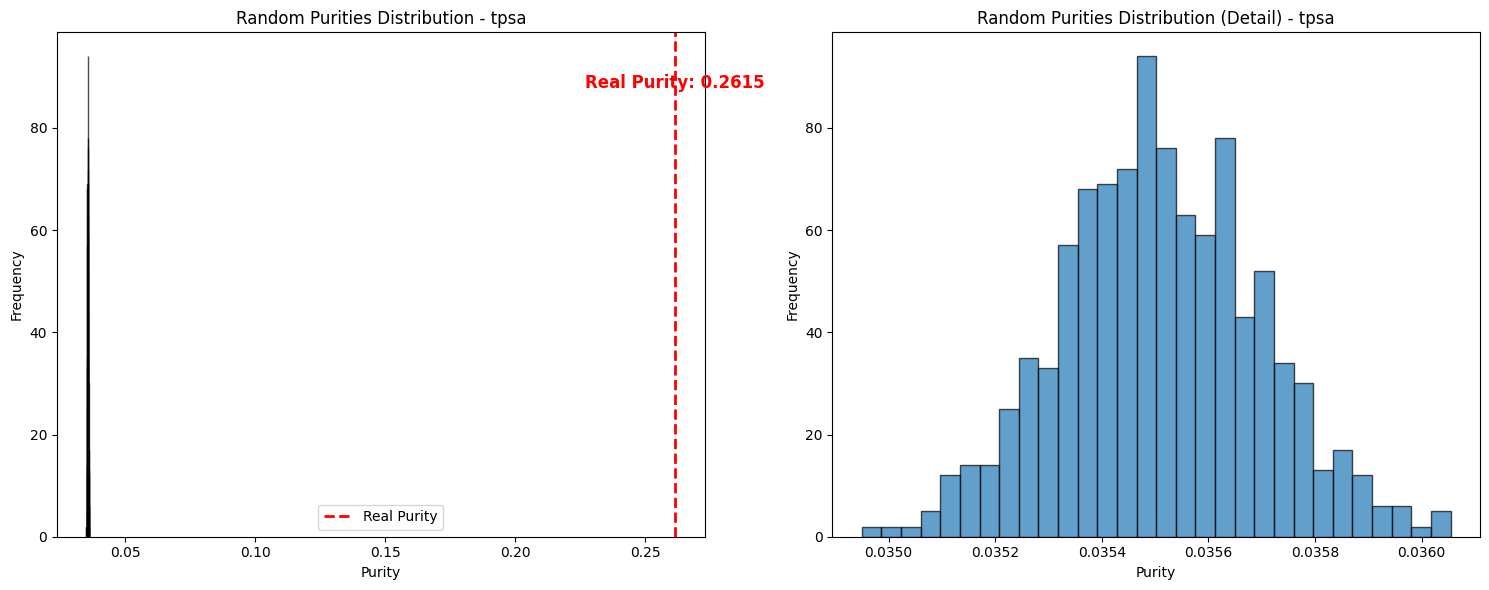

9 0.0 tpsa


In [ ]:
lsh_purity_real = lsh_forest_purity(s, t, labels)
random_purities = []

for _ in range(num_permutations):
    shuffled_labels = np.random.permutation(labels)
    random_purity = lsh_forest_purity(s, t, shuffled_labels)
    random_purities.append(random_purity)

random_purities = np.array(random_purities)
fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
axs[0].set_title(f"Random Homophily Ratios Distribution - {label_type}")
axs[0].set_xlabel("Homophily Ratio")
axs[0].set_ylabel("Frequency")
axs[0].legend()
axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
            color='red', ha='center', va='center', fontsize=12, fontweight='bold')

axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[1].set_title(f"Random Homophily Ratios Distribution (Detail) - {label_type}")
axs[1].set_xlabel("Homophily Ratio")
axs[1].set_ylabel("Frequency")

plt.tight_layout() 
plt.savefig(f"{output_dir}/random_homophily_ratios_{label_type}.png")
plt.show()

p_value = np.mean(random_purities >= lsh_purity_real)
print(id, p_value, label_type)

scores.append([id, p_value, label_type])

if label_type == "3":
    p_values_3.append(p_value)
else:
    p_values_full.append(p_value)

# homophily ratio analysis

In [6]:
def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t]) 
    purity = np.sum(matches) / len(matches)
    return purity

In [7]:
df = pd.read_csv("../../data/processed/surechembl/molecular_descriptors_with_date.csv")

date_dict = {smiles: years for smiles, years in zip(df["SMILES"], df["DATE"])}
mw_dict = {smiles: mw for smiles, mw in zip(df["SMILES"], df["MolecularWeight"])}
tpsa_dict = {smiles: tpa for smiles, tpa in zip(df["SMILES"], df["TPSA"])}
logp_dict = {smiles: logp for smiles, logp in zip(df["SMILES"], df["LogP"])}

In [ ]:
homophily_labels = []

for i in range(0, 10):
    id = i
    output_dir = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{i}"

    s_path = os.path.join(output_dir, "s.pkl")
    t_path = os.path.join(output_dir, "t.pkl")
    smiles_path = os.path.join(output_dir, "smiles.pkl")

    s = pickle_load(s_path)
    t = pickle_load(t_path)
    smiles = pickle_load(smiles_path)

    tpsa = []
    mw = []
    logp = []
    years = []
    for smile in tqdm(smiles):
        tpsa.append(tpsa_dict[smile])
        mw.append(mw_dict[smile])
        logp.append(logp_dict[smile])
        years.append(int(date_dict[smile]))

    labels_full = [year for year in years]    
    labels_full = np.array(labels_full)
    lsh_purity_real = lsh_forest_purity(s, t, labels_full)
    homophily_labels.append([id, lsh_purity_real, "year"])

    counter_year = collections.Counter(years)
    counter_year_keys = sorted(list(counter_year.keys()))

    count = []
    for key in counter_year_keys:
        count.append(counter_year[key])

    for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:
        sorted_data = sorted(data)
        sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
        data_label = [0 for _ in range(len(data))]

        label = 0
        index = 0

        for i in count:
            index_next = index + i
            for j in range(index, index_next):
                data_label[sorted_data_index[j]] = label
            index = index_next
            label += 1

        labels = data_label
        labels = np.array(labels)

        lsh_purity_real = lsh_forest_purity(s, t, labels)
        homophily_labels.append([id, lsh_purity_real, label_type])

100%|██████████| 996451/996451 [00:06<00:00, 158344.27it/s]


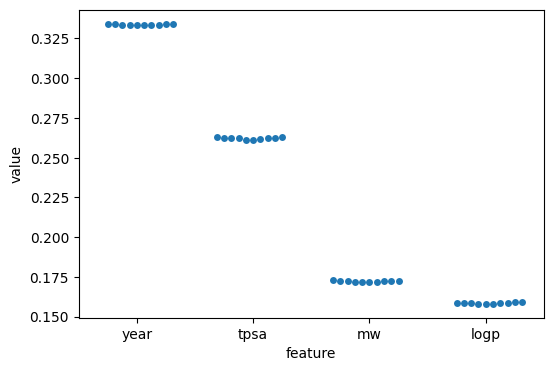

In [5]:
import seaborn as sns
df = pd.DataFrame(homophily_labels, columns=["ID", "value", "feature"])
plt.figure(figsize=(6, 4))
sns.swarmplot(x="feature", y="value", data=df)
plt.savefig("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/homophily_labels.png")

# Run All Test

In [3]:
df = pd.read_csv(f"../../data/processed/surechembl/molecular_descriptors_with_date.csv")

def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t]) 
    purity = np.sum(matches) / len(matches)
    return purity

In [4]:
num_permutations = 1000
scores = []

100%|██████████| 996411/996411 [00:44<00:00, 22388.93it/s]


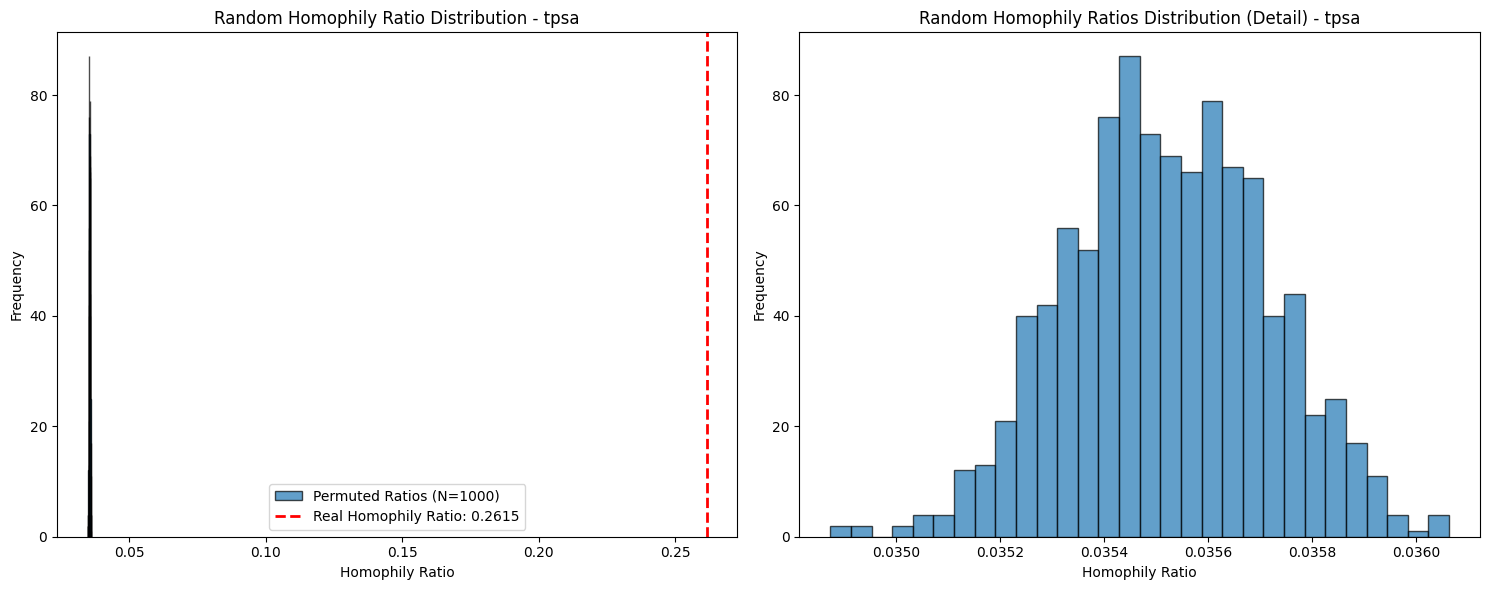

0 0.0 tpsa


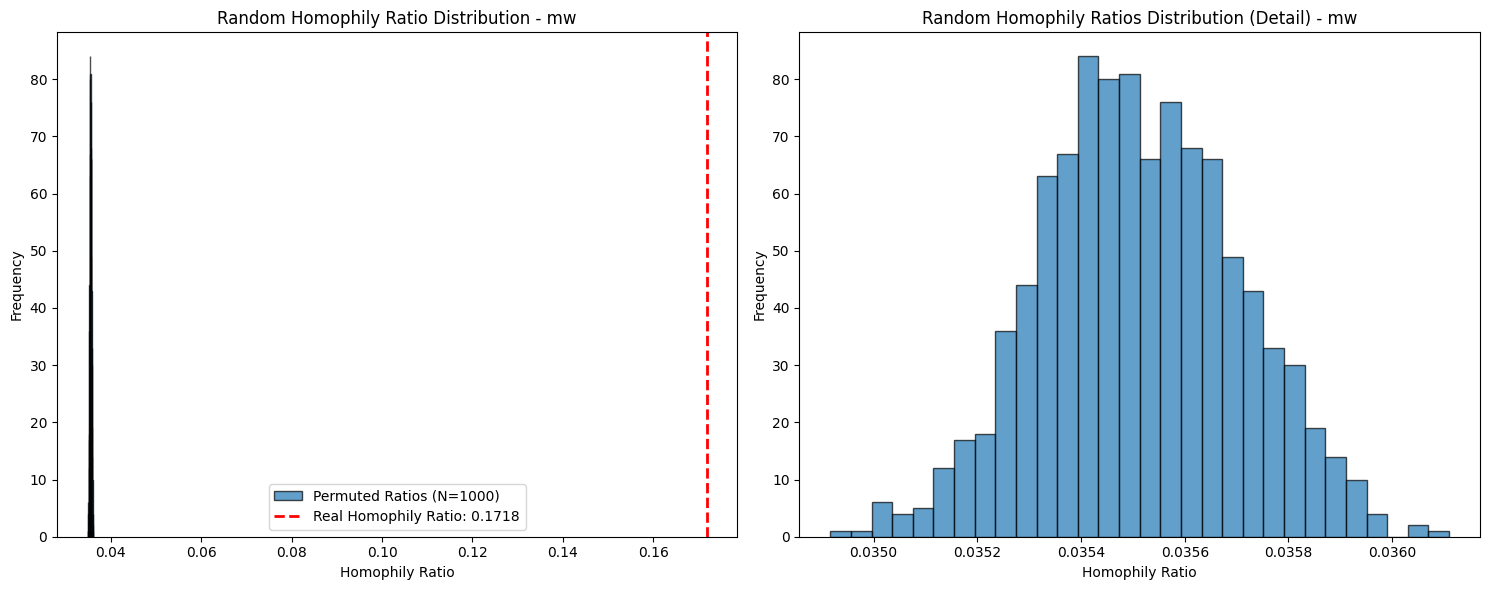

0 0.0 mw


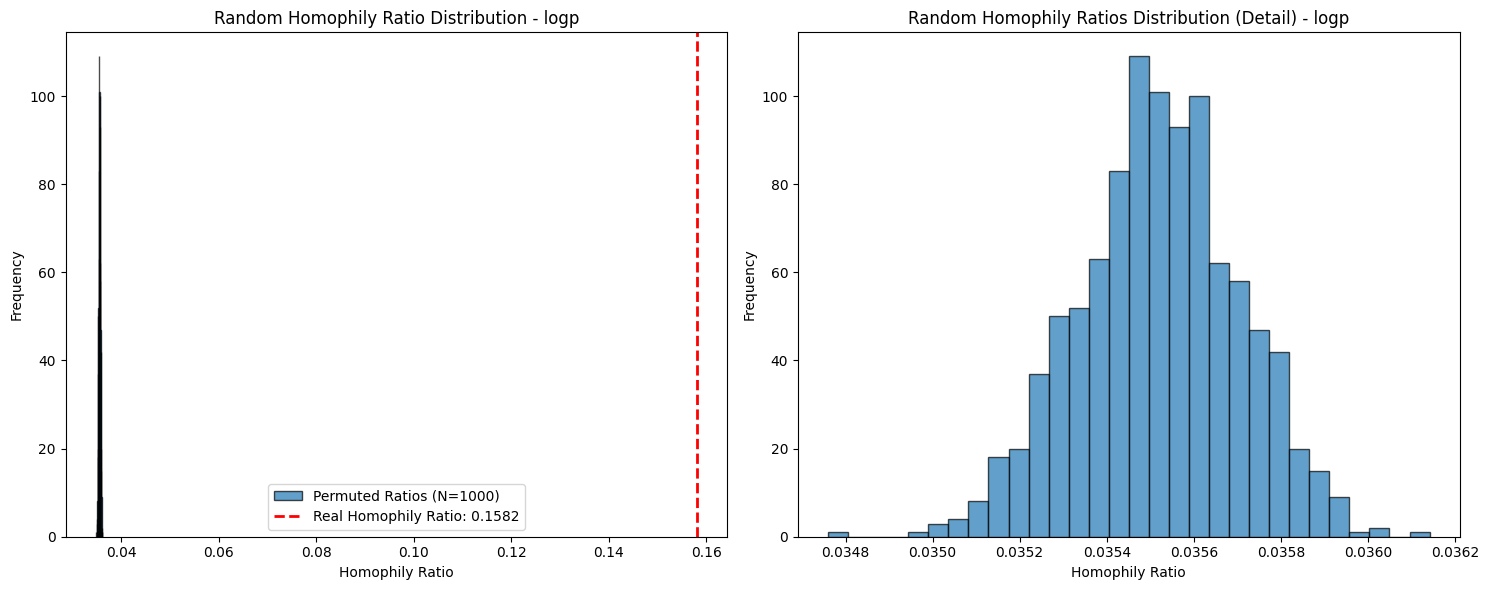

0 0.0 logp


100%|██████████| 996396/996396 [00:49<00:00, 19966.94it/s]


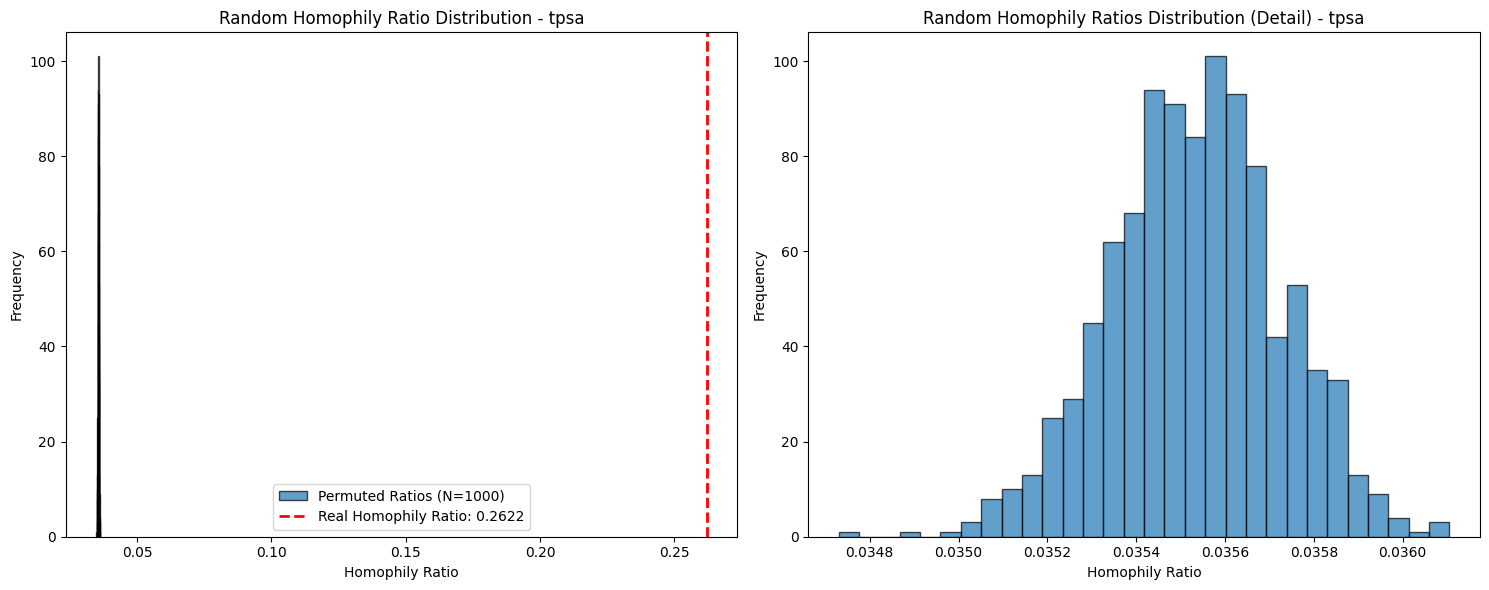

1 0.0 tpsa


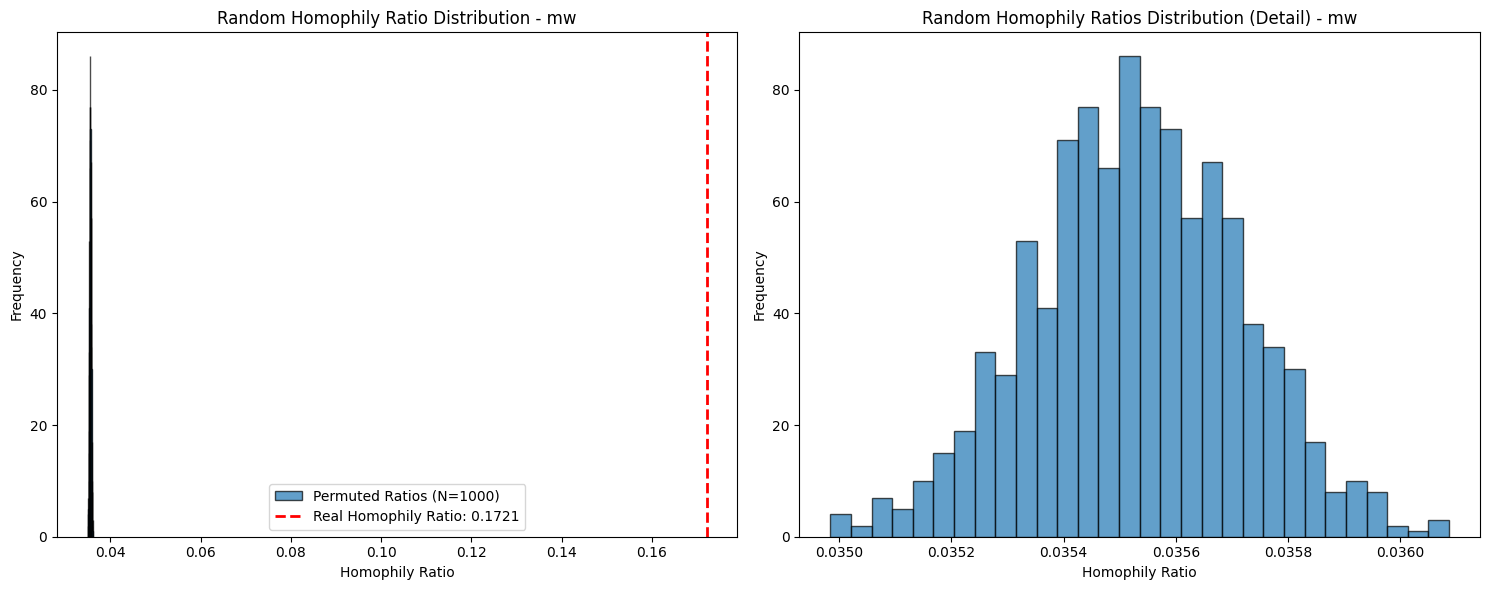

1 0.0 mw


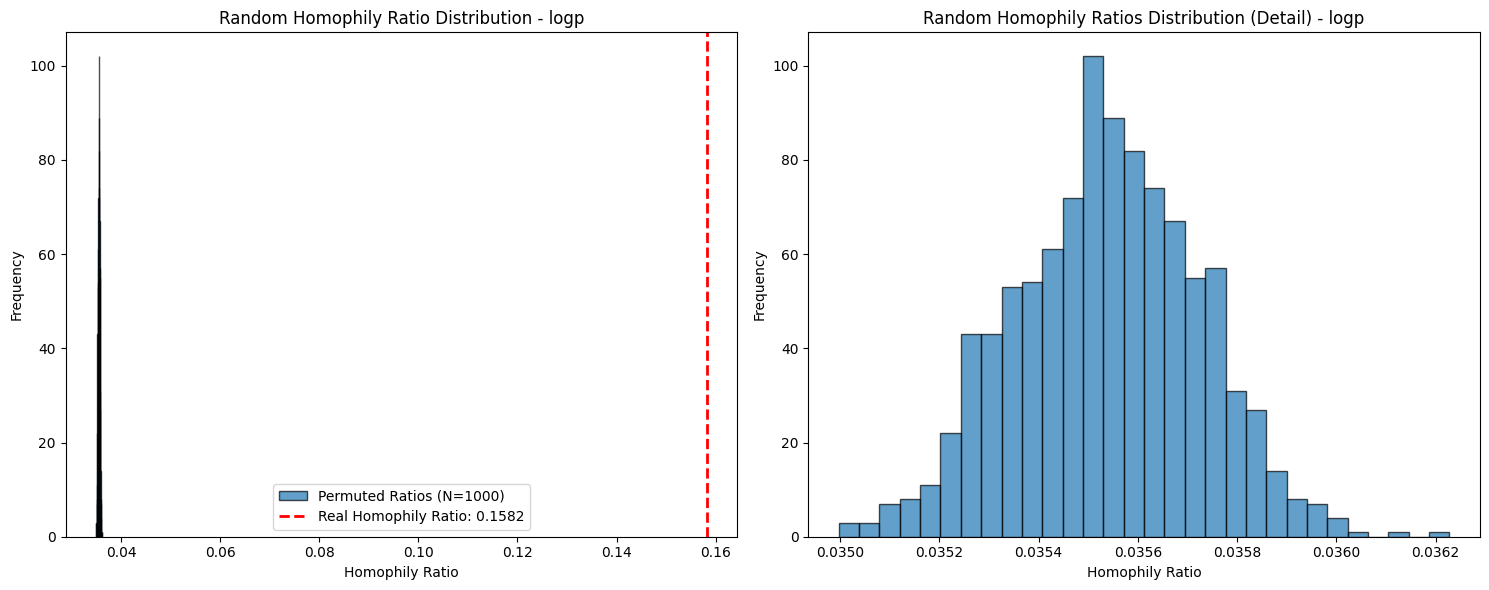

1 0.0 logp


100%|██████████| 996381/996381 [00:49<00:00, 20137.05it/s] 


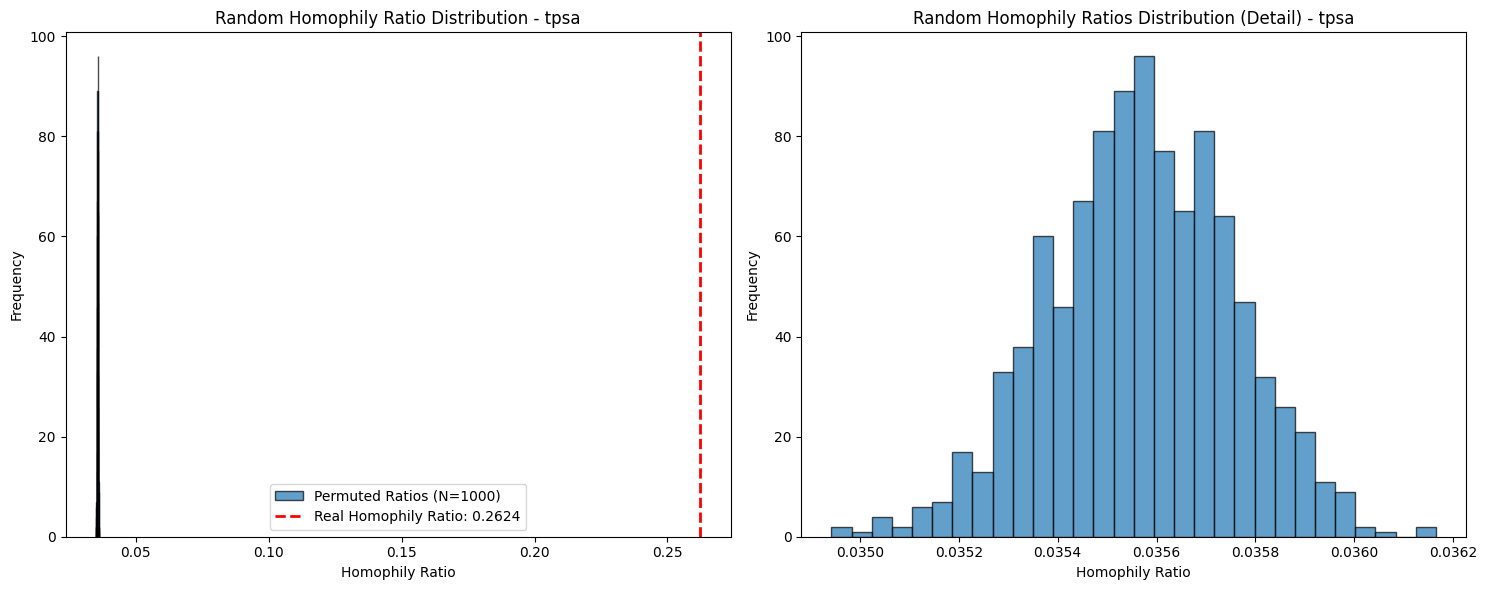

2 0.0 tpsa


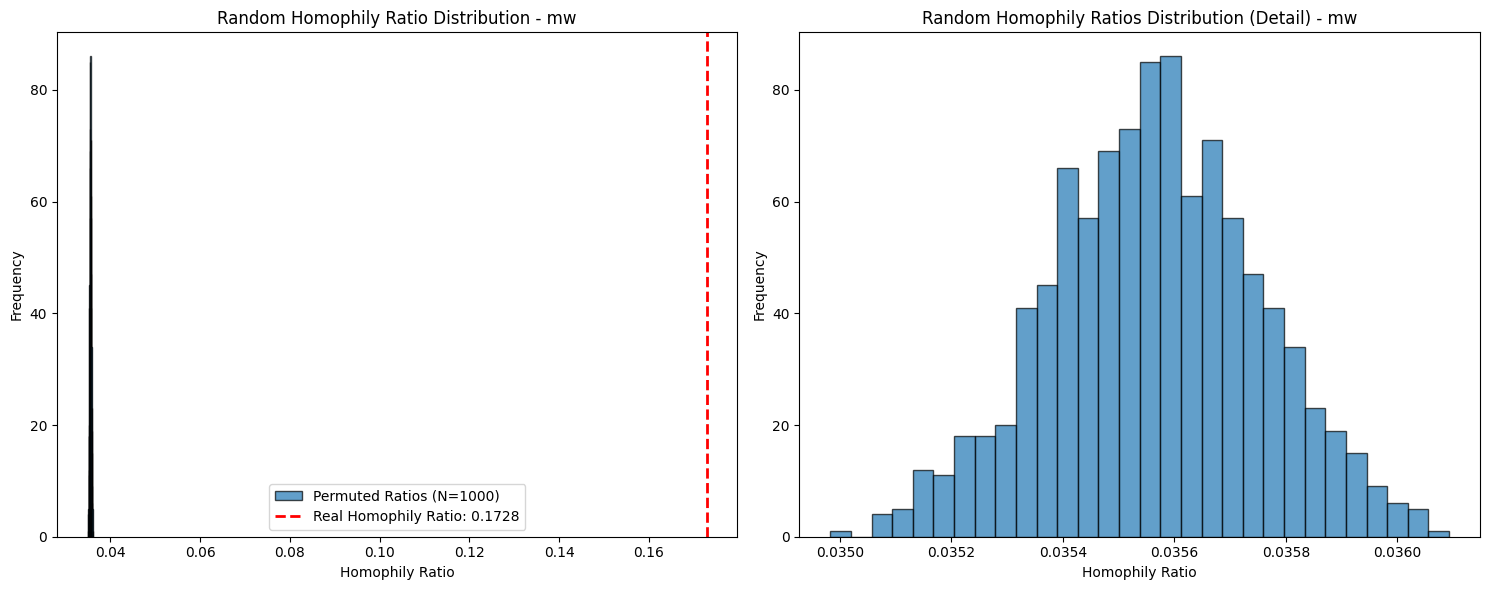

2 0.0 mw


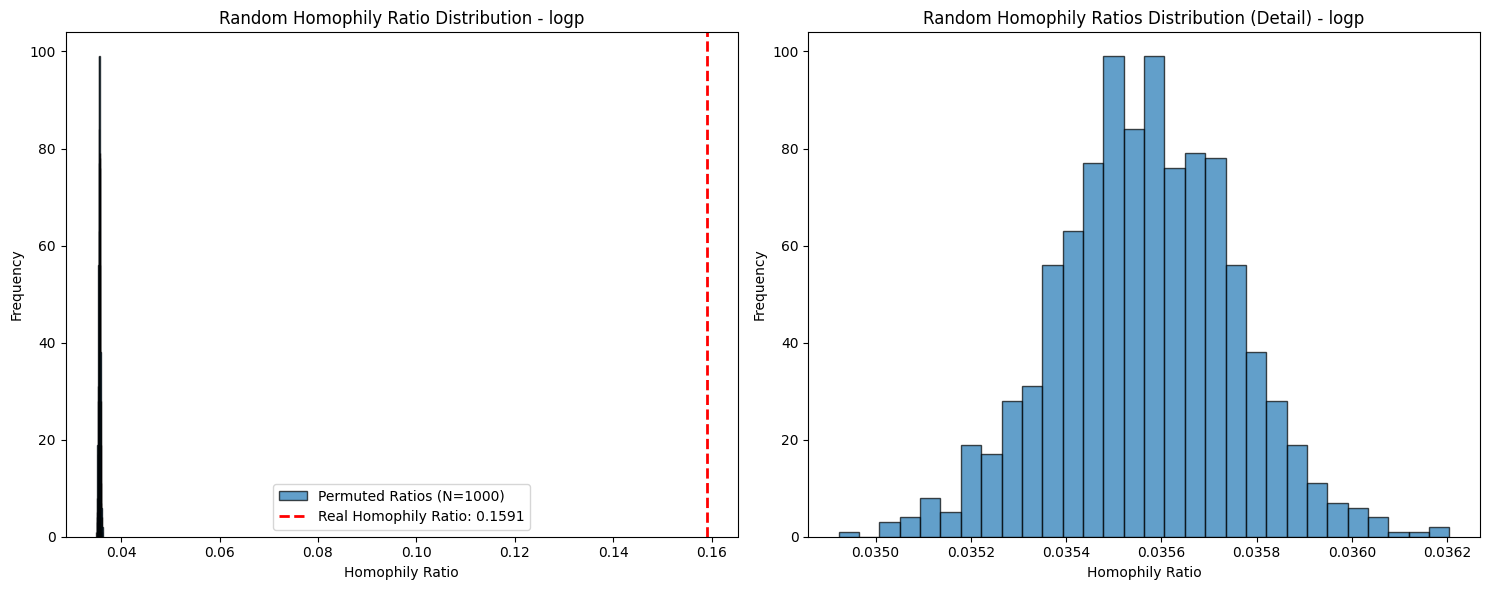

2 0.0 logp


100%|██████████| 996587/996587 [00:45<00:00, 22144.65it/s]


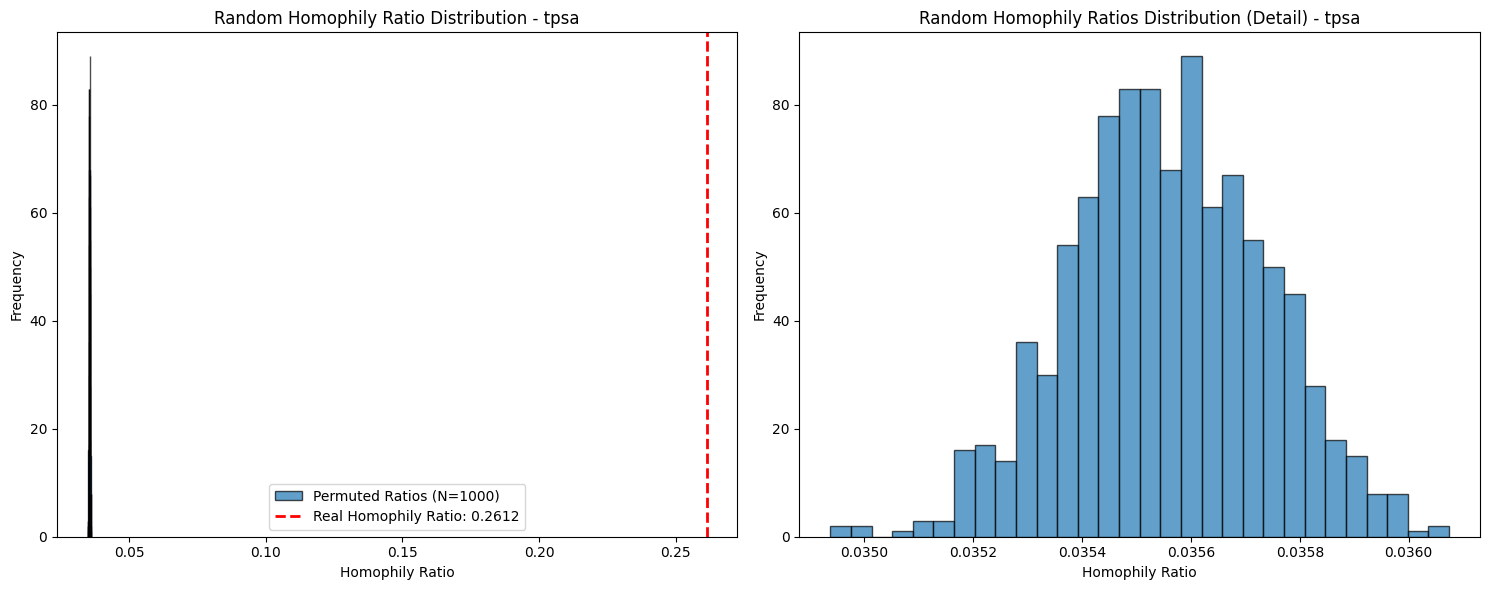

3 0.0 tpsa


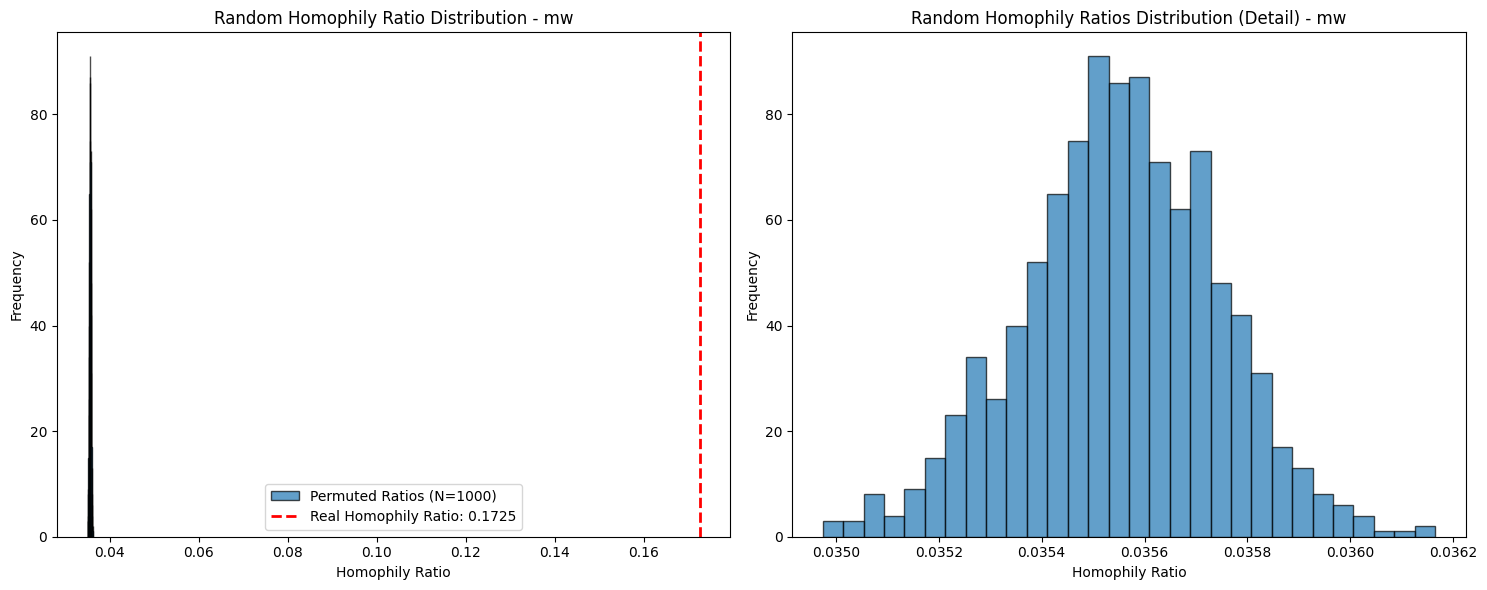

3 0.0 mw


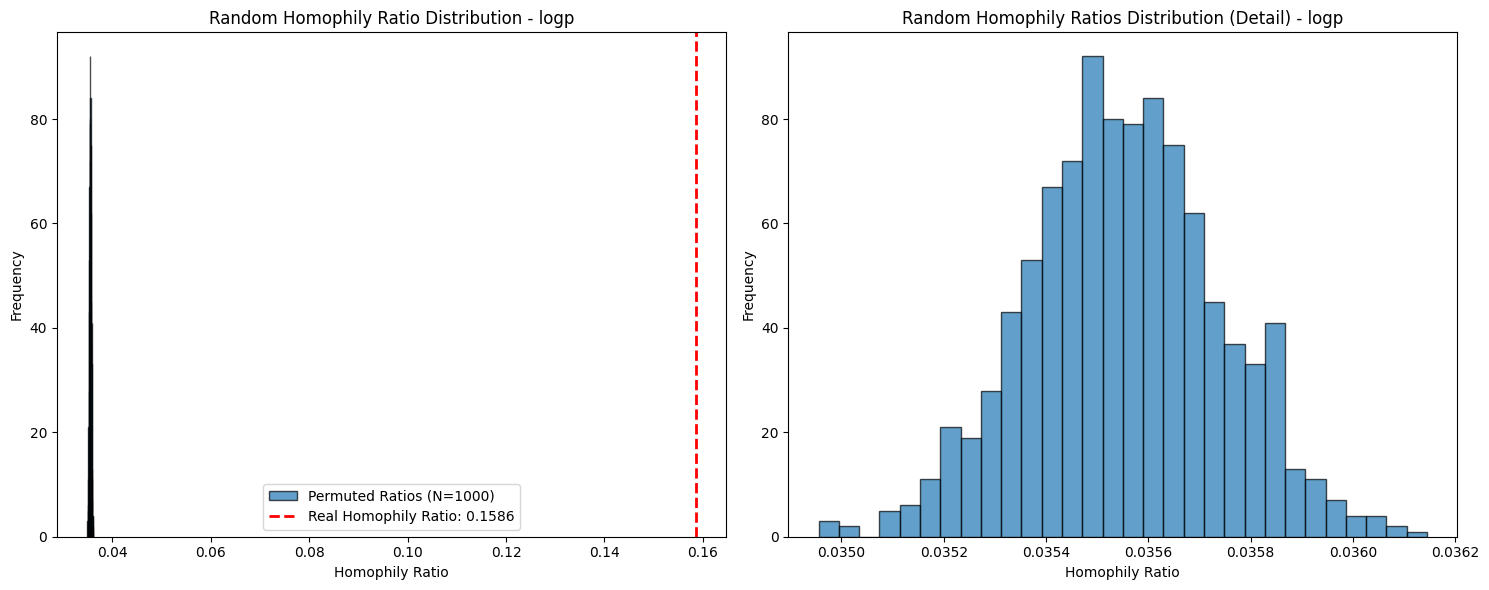

3 0.0 logp


100%|██████████| 996441/996441 [01:06<00:00, 14939.30it/s]


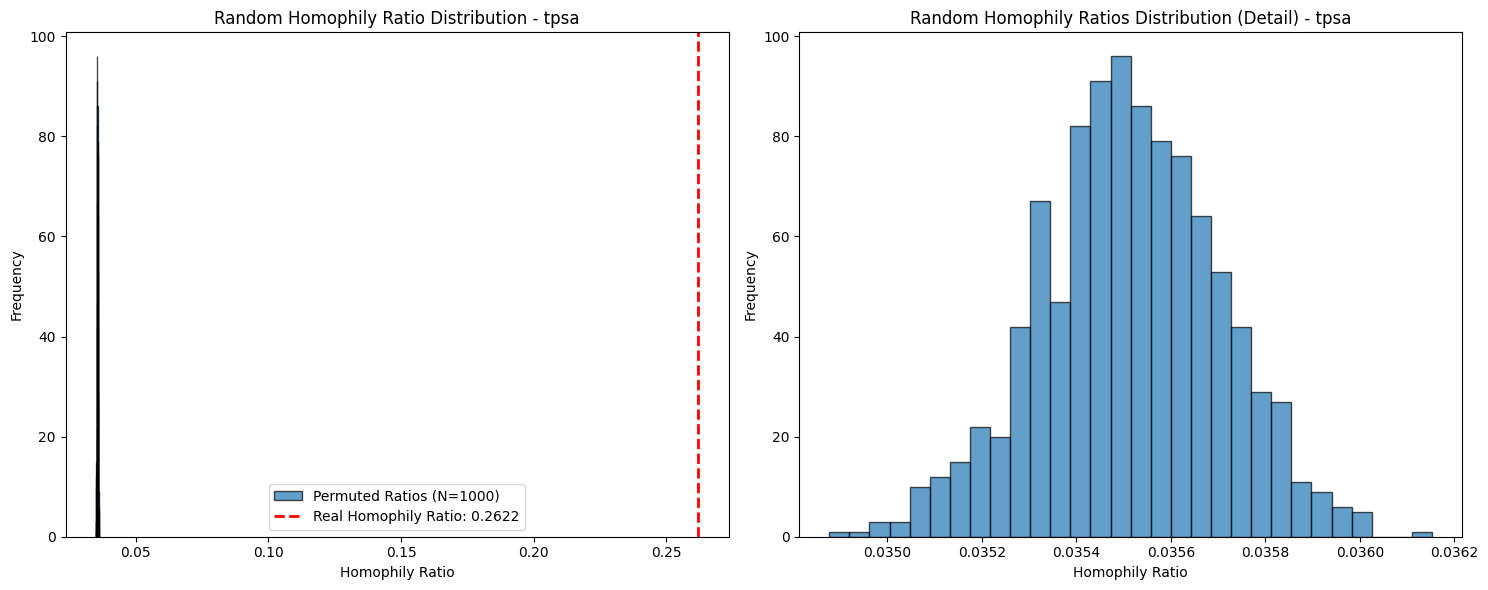

4 0.0 tpsa


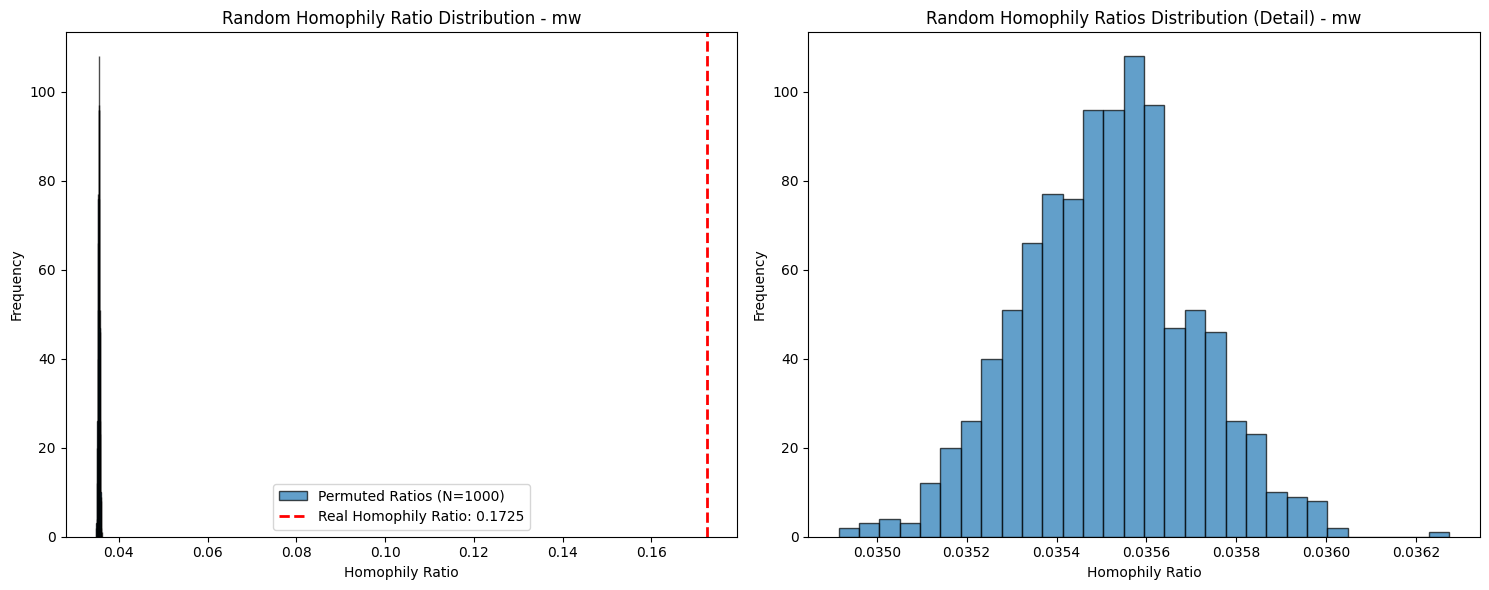

4 0.0 mw


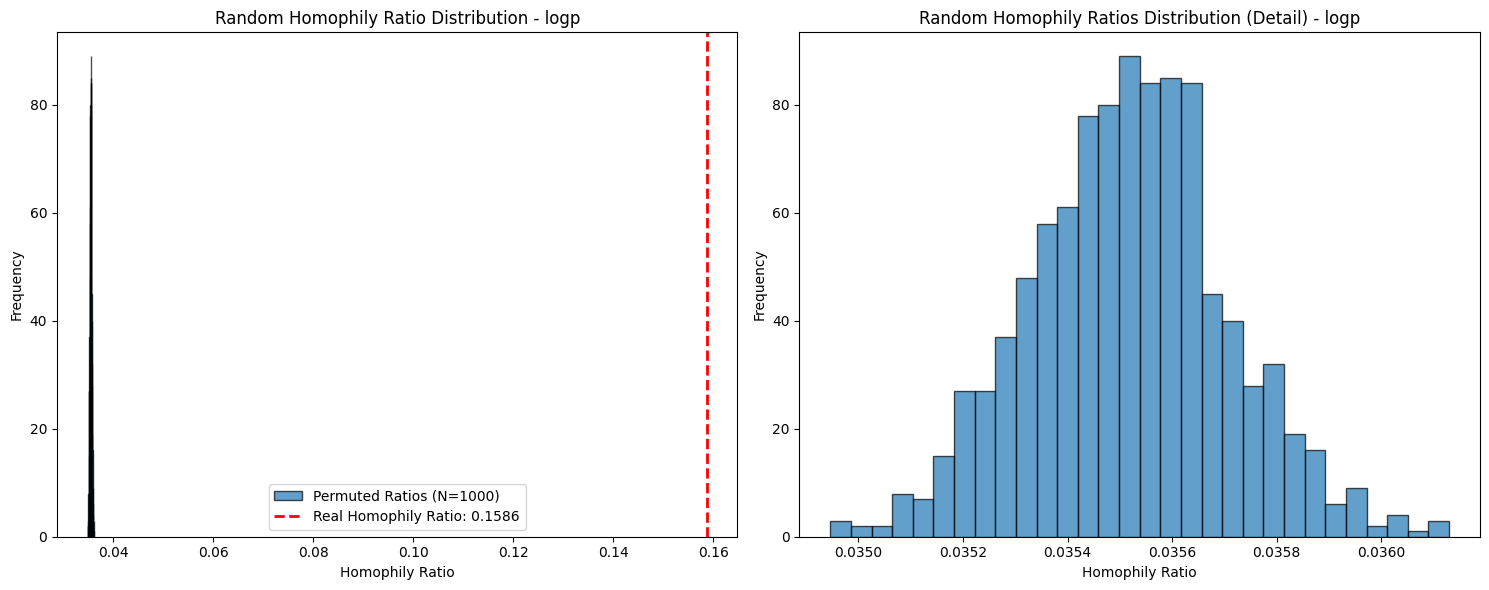

4 0.0 logp


100%|██████████| 996439/996439 [00:55<00:00, 17794.61it/s]


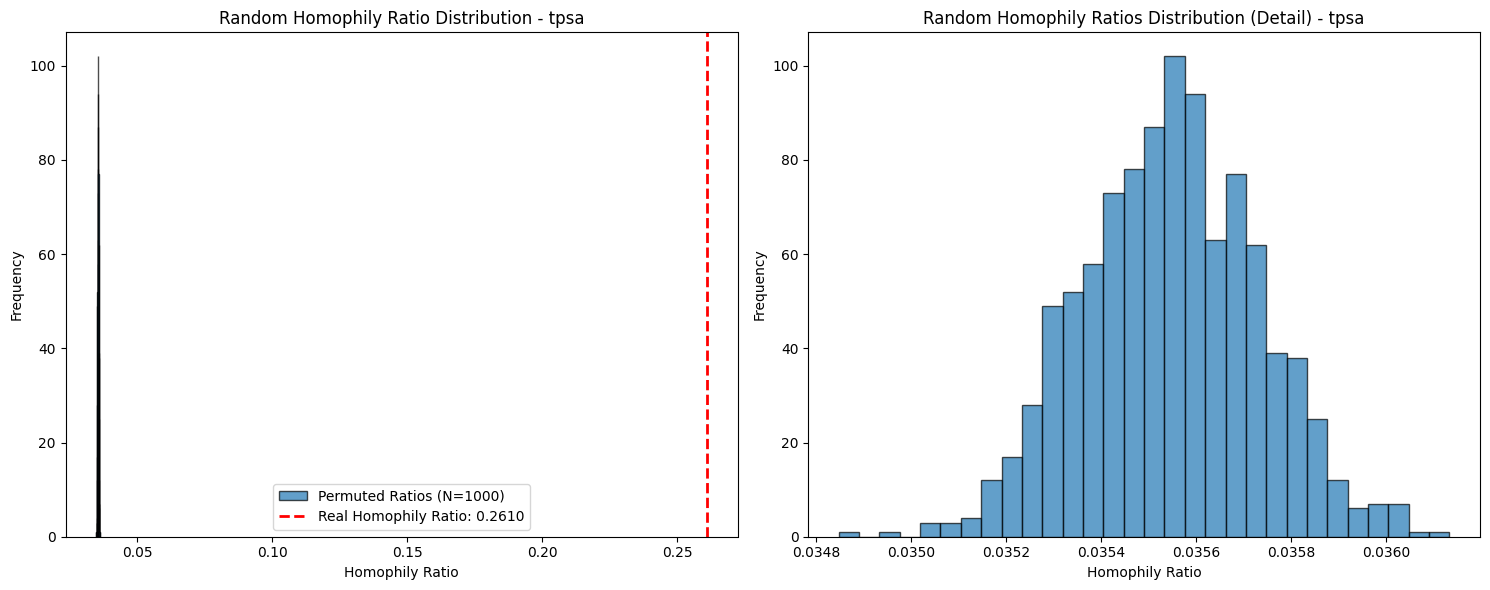

5 0.0 tpsa


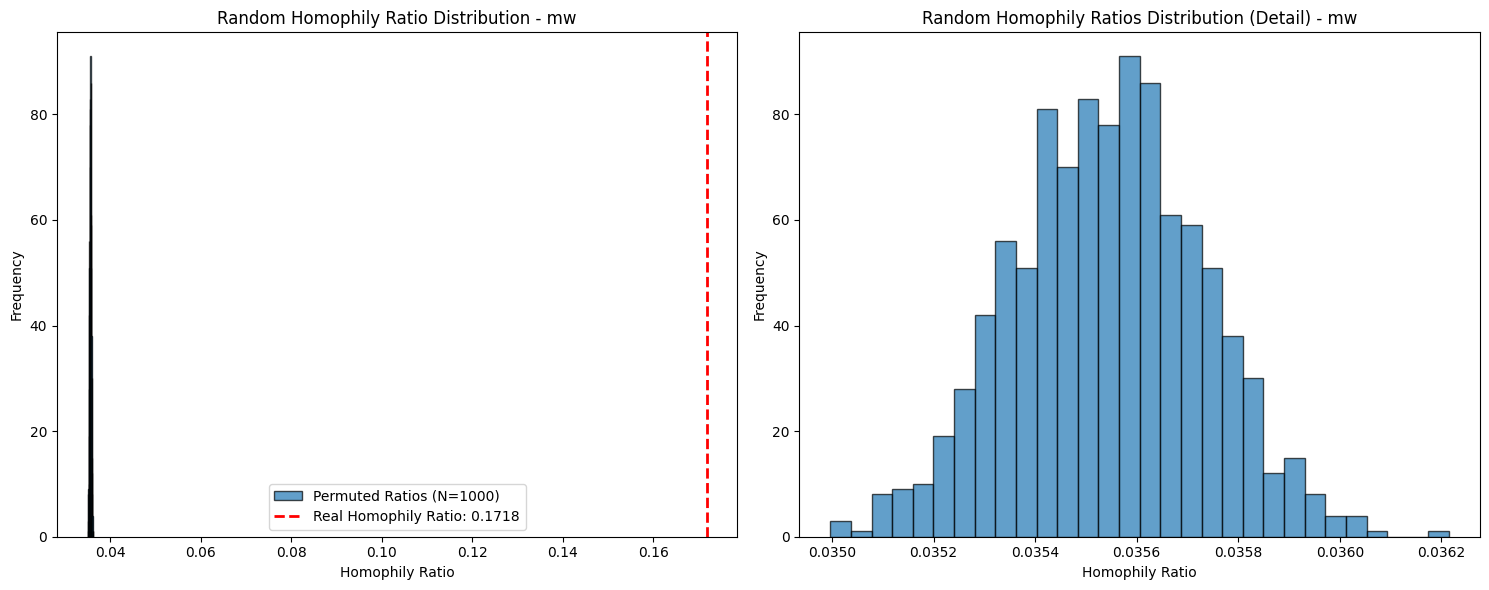

5 0.0 mw


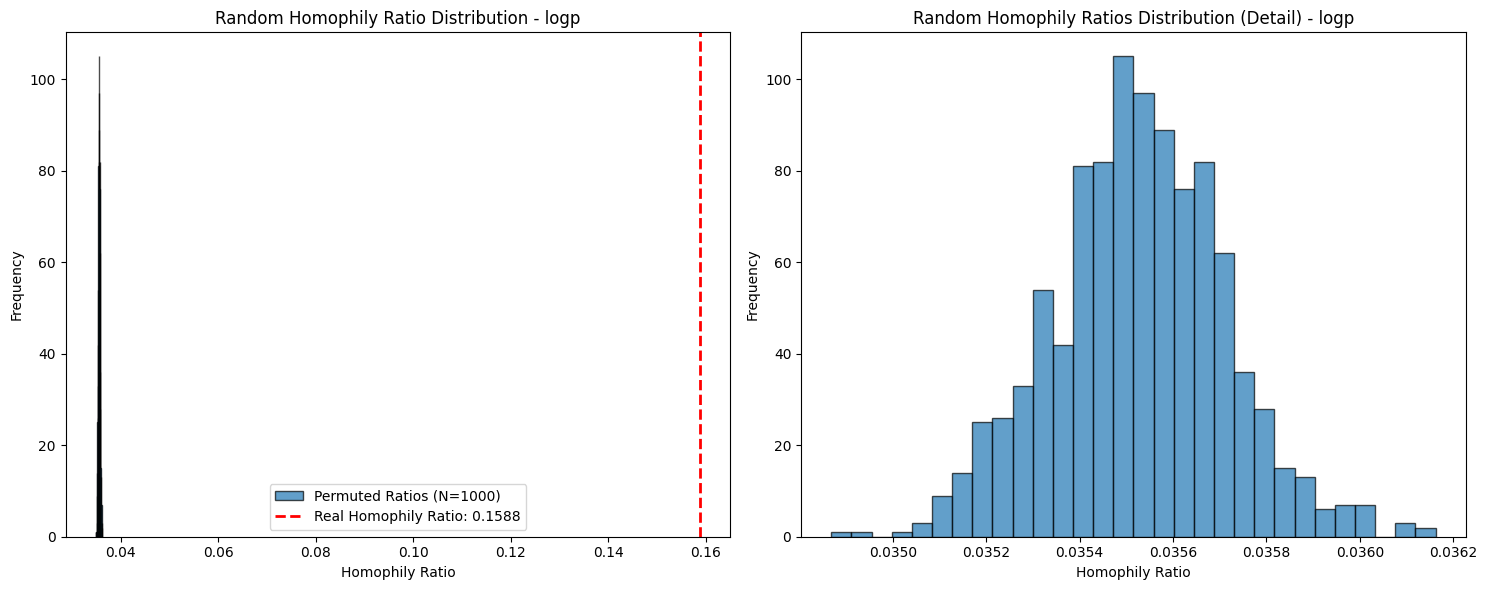

5 0.0 logp


100%|██████████| 996525/996525 [01:02<00:00, 15945.90it/s]


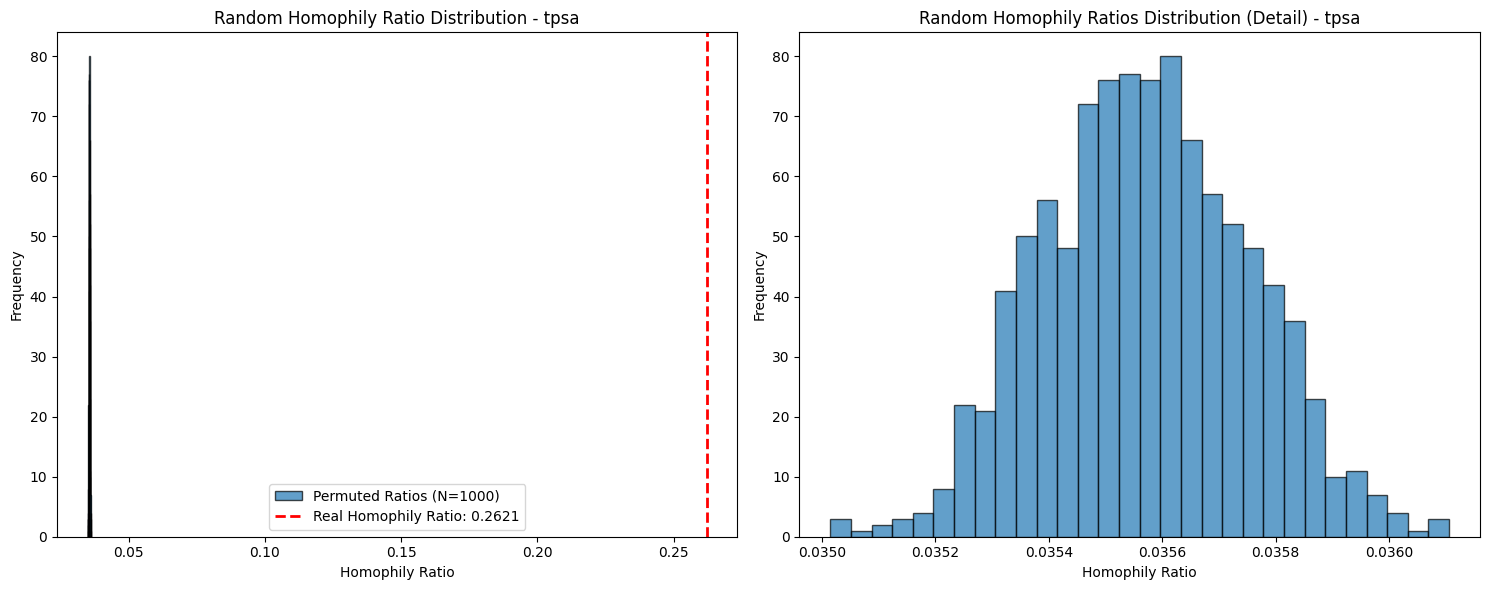

6 0.0 tpsa


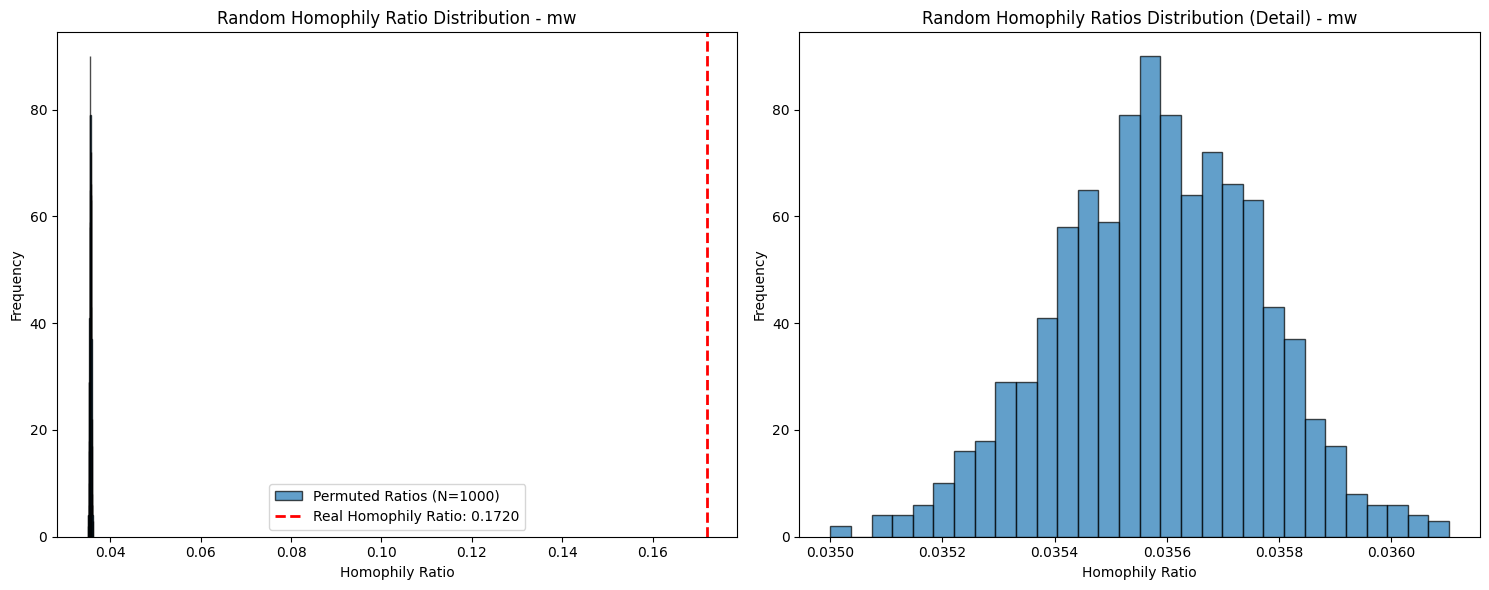

6 0.0 mw


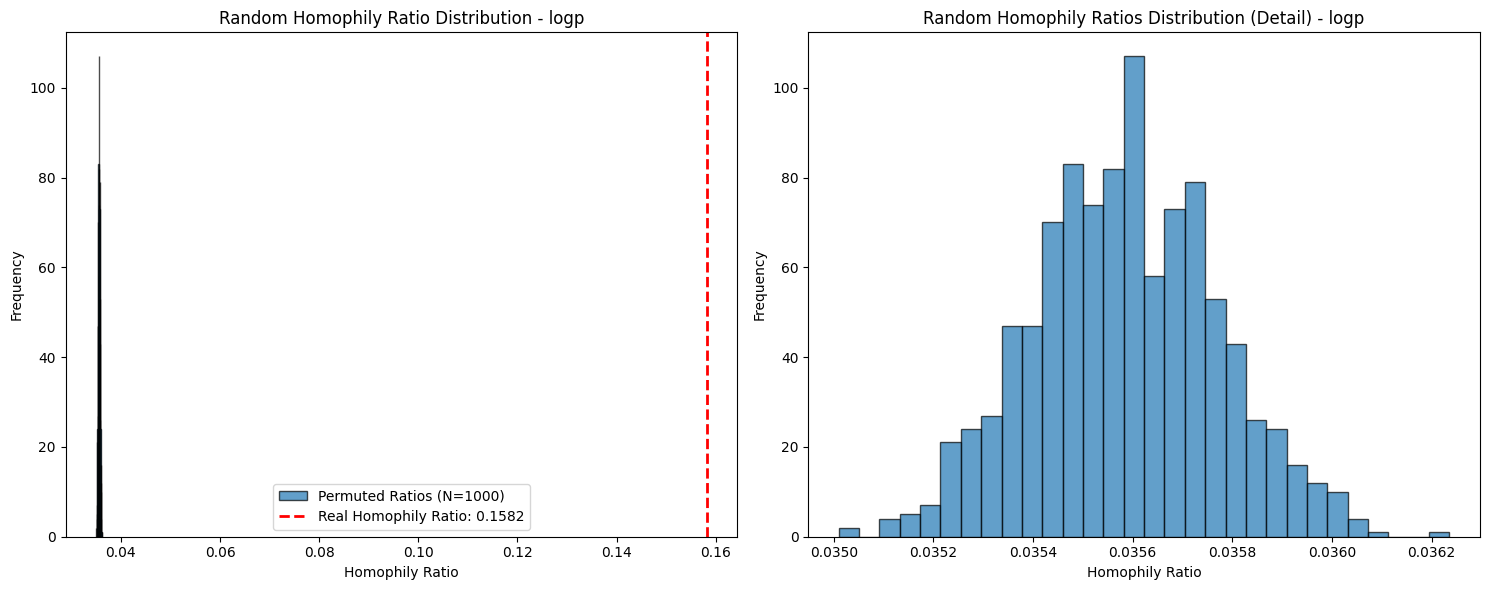

6 0.0 logp


100%|██████████| 996566/996566 [00:52<00:00, 19054.01it/s]


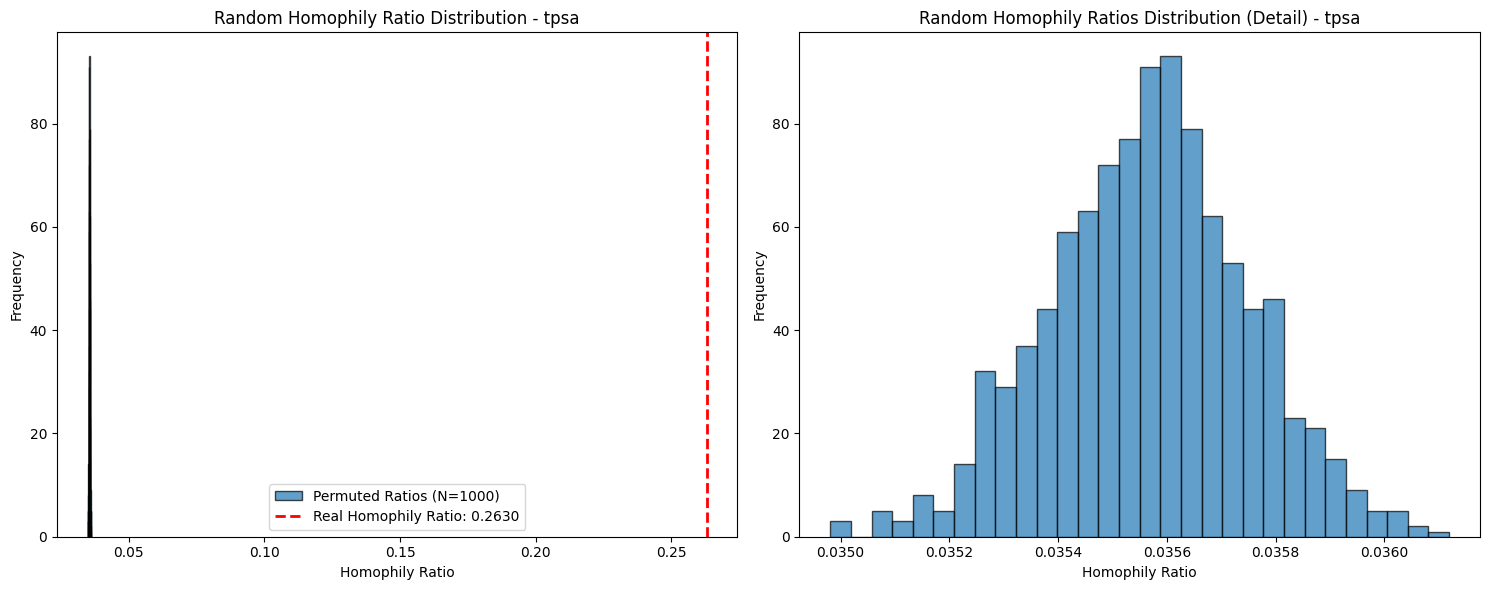

7 0.0 tpsa


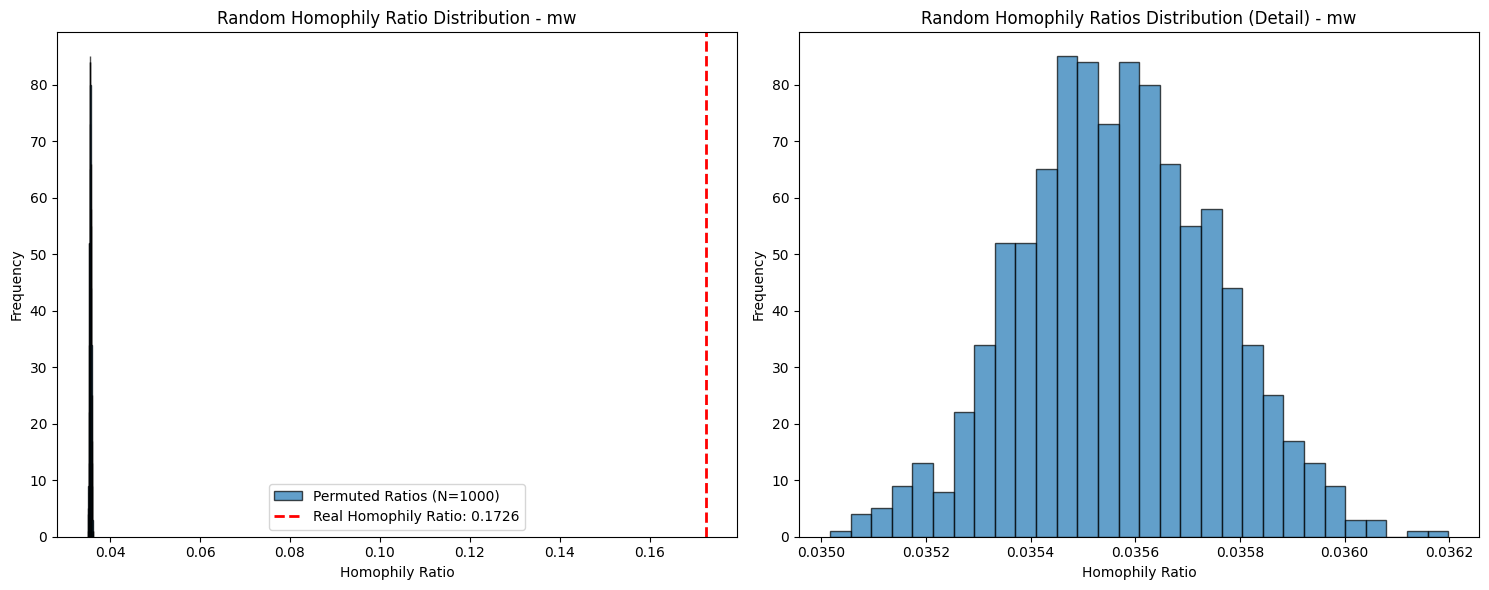

7 0.0 mw


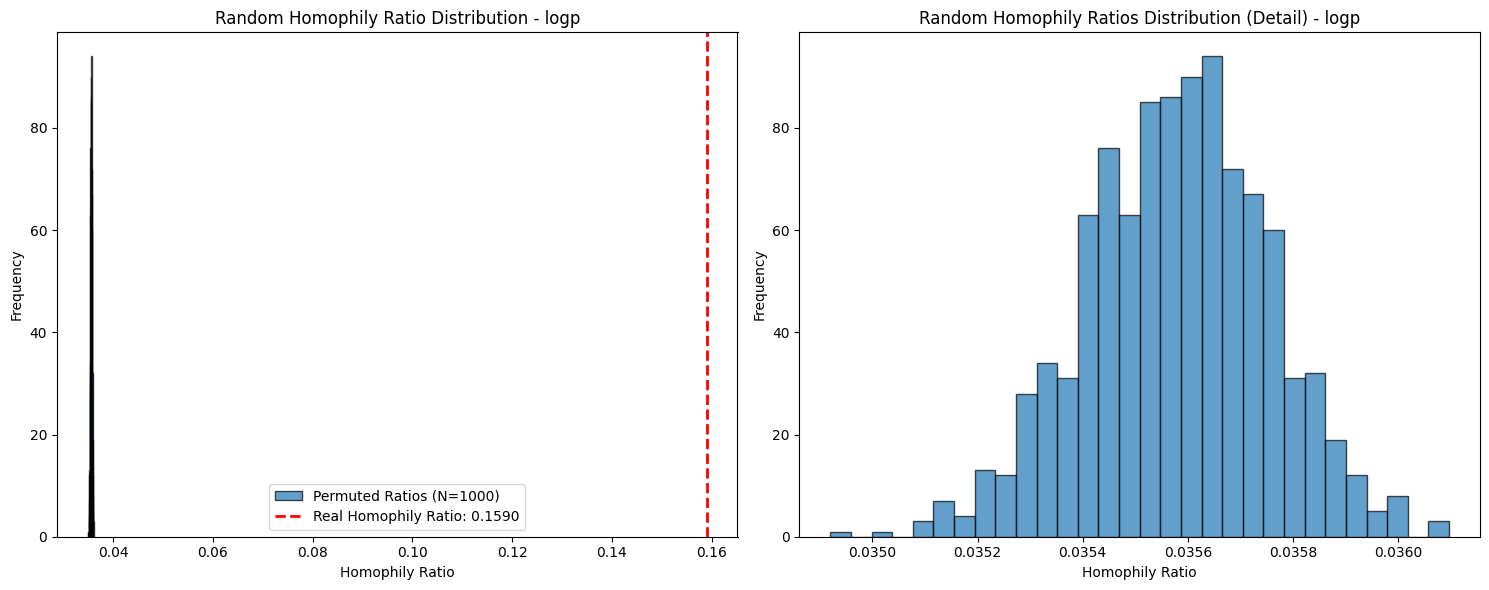

7 0.0 logp


100%|██████████| 996546/996546 [01:12<00:00, 13764.69it/s]


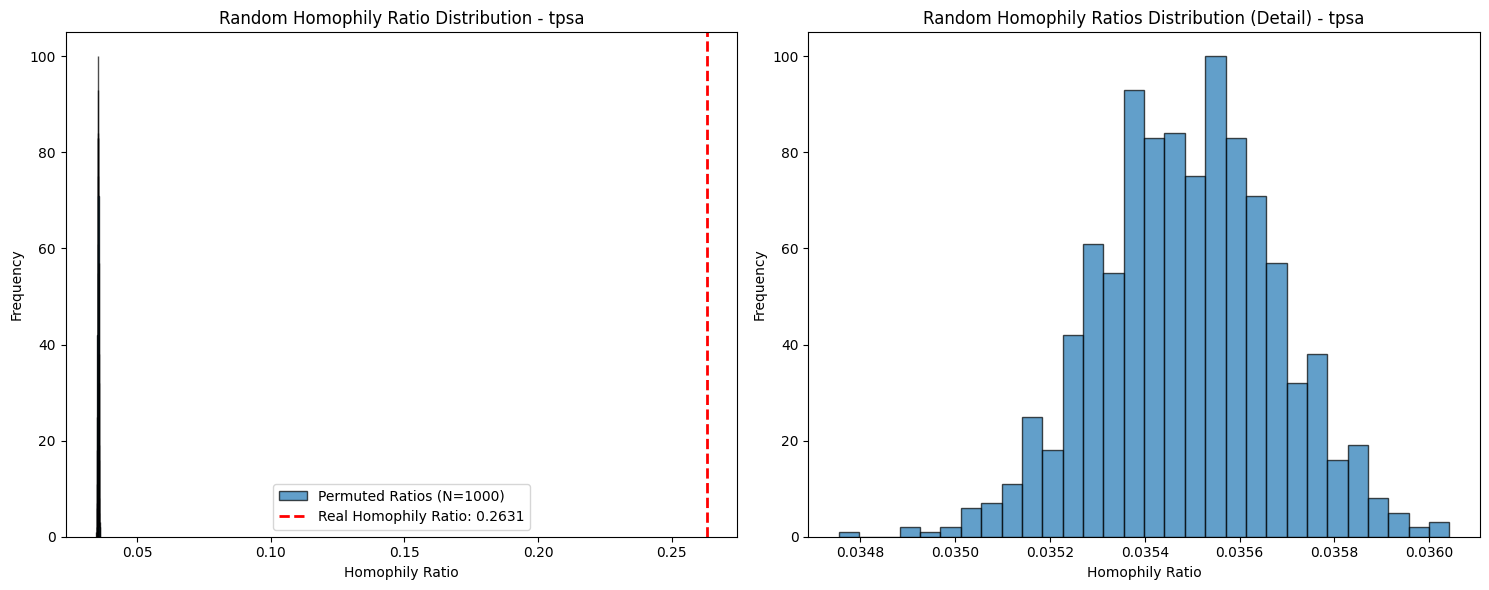

8 0.0 tpsa


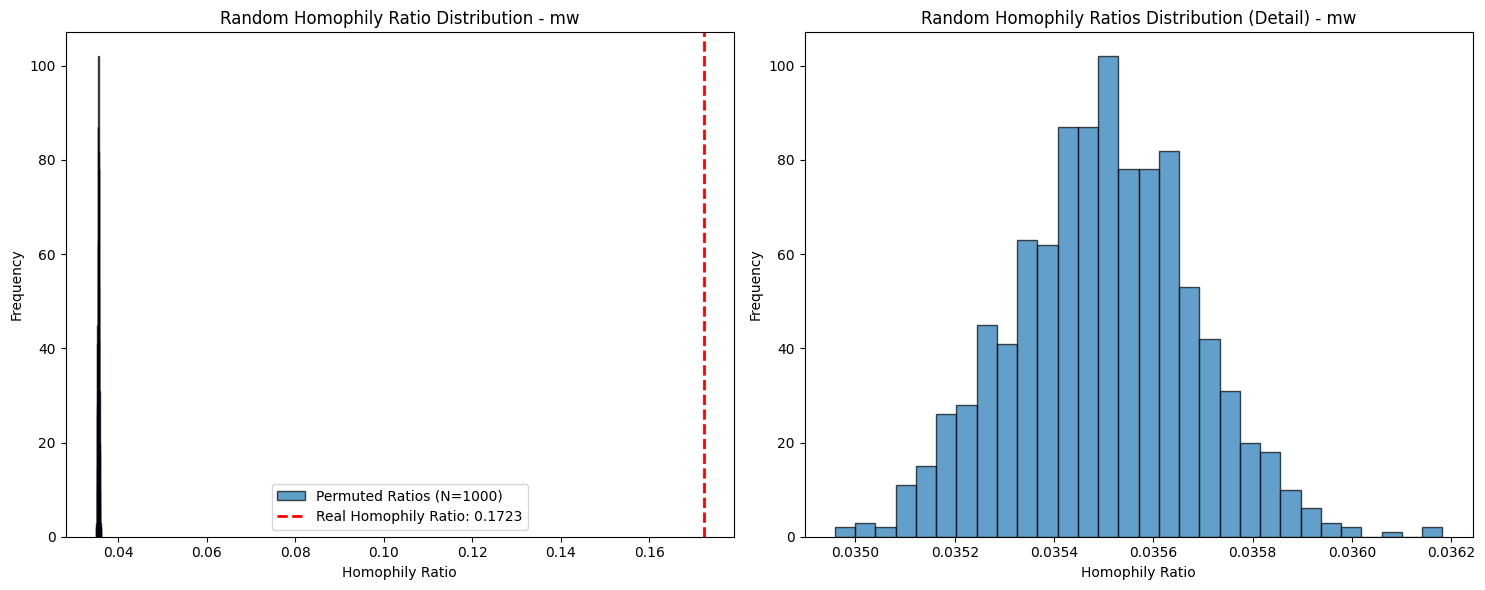

8 0.0 mw


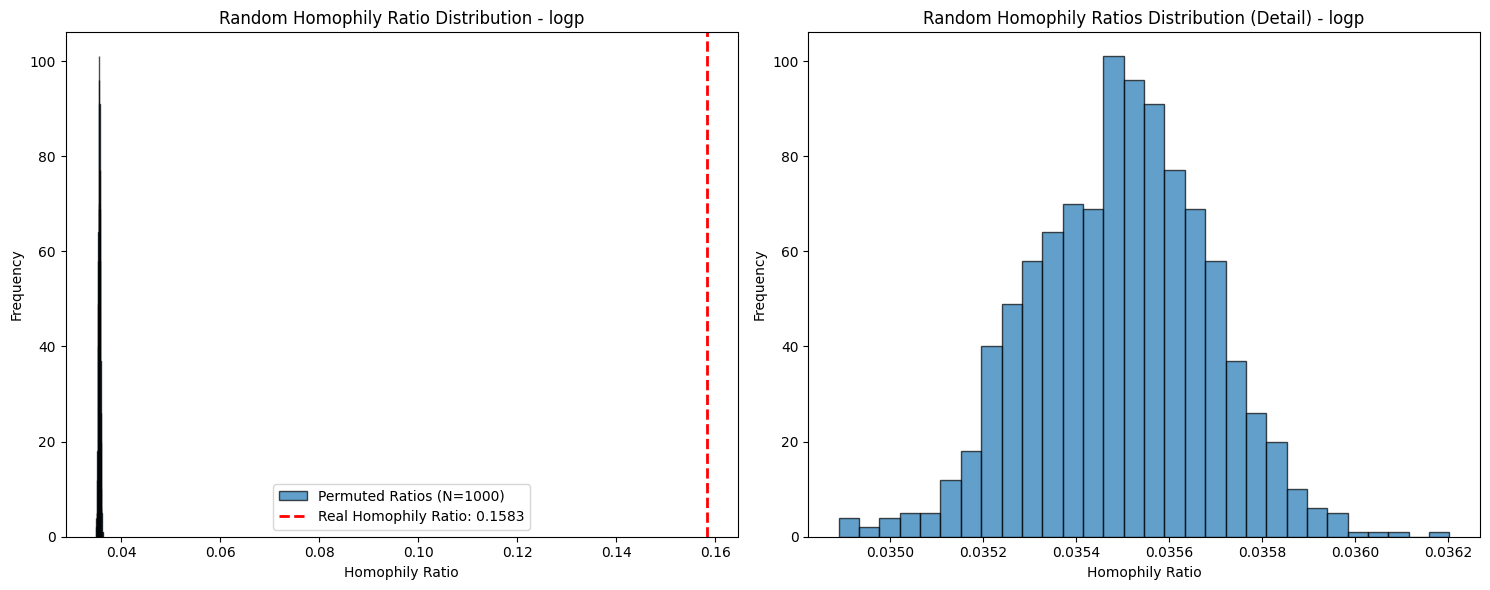

8 0.0 logp


100%|██████████| 996451/996451 [00:43<00:00, 22801.70it/s]


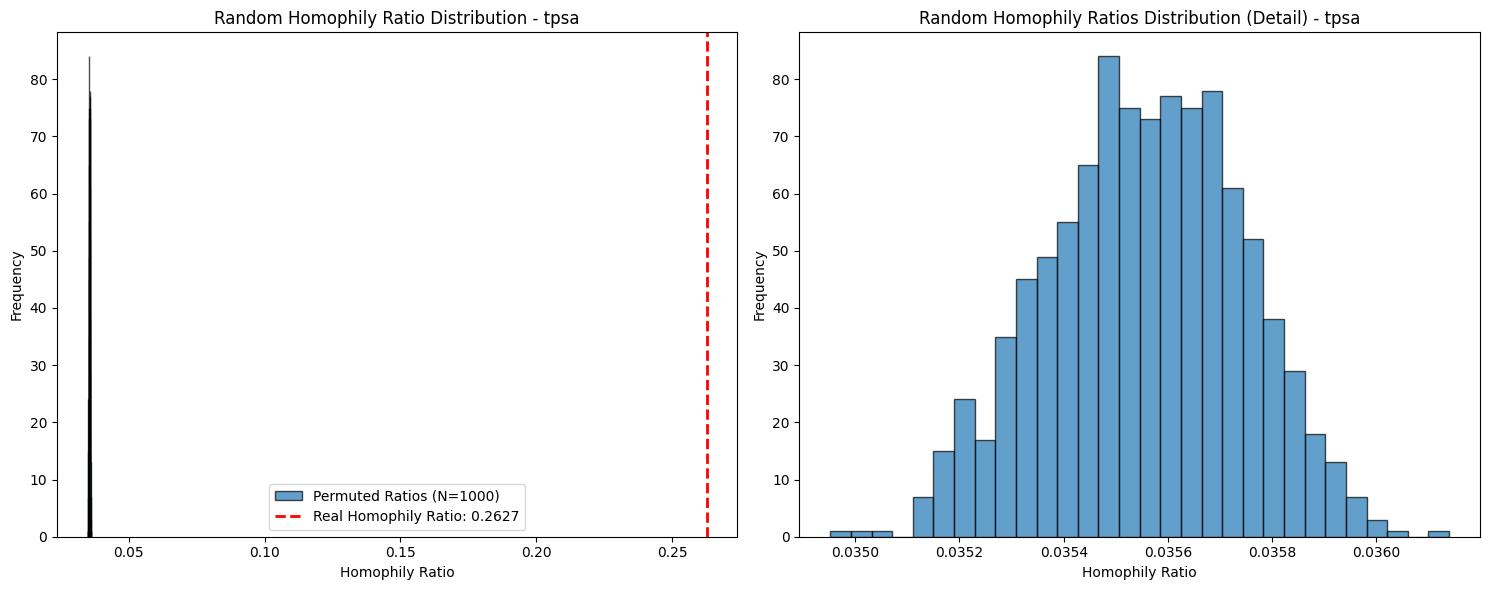

9 0.0 tpsa


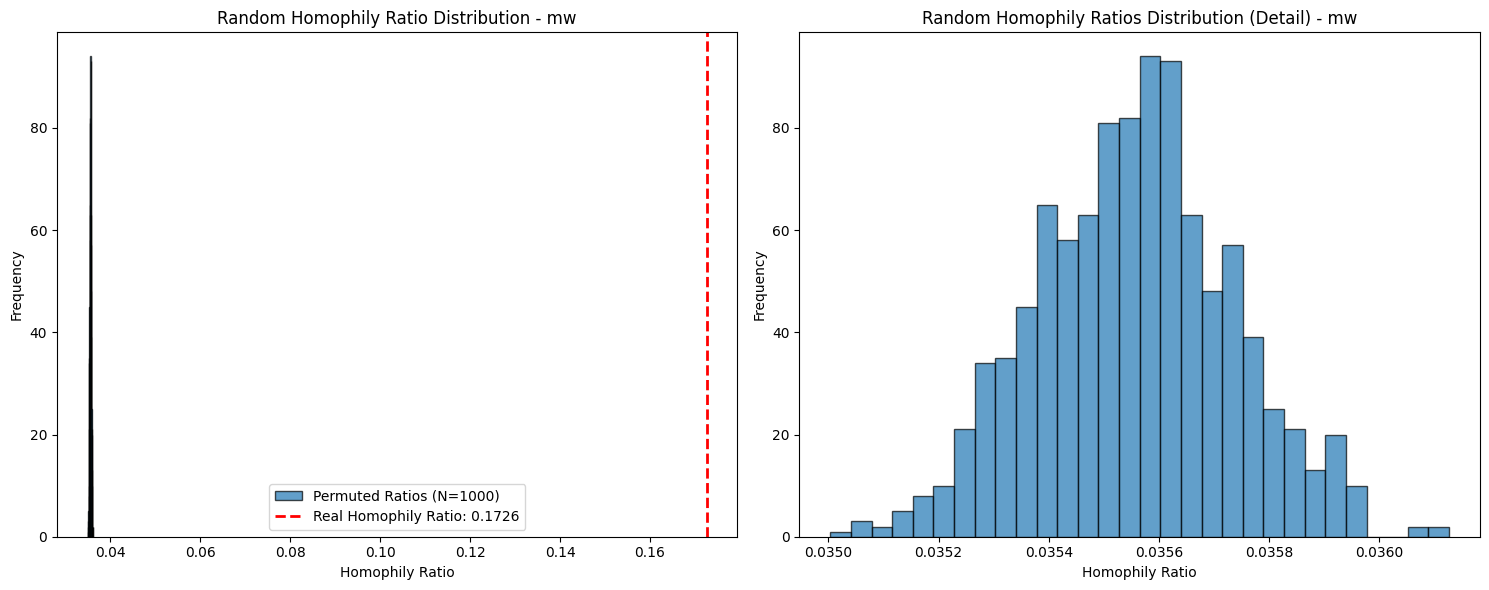

9 0.0 mw


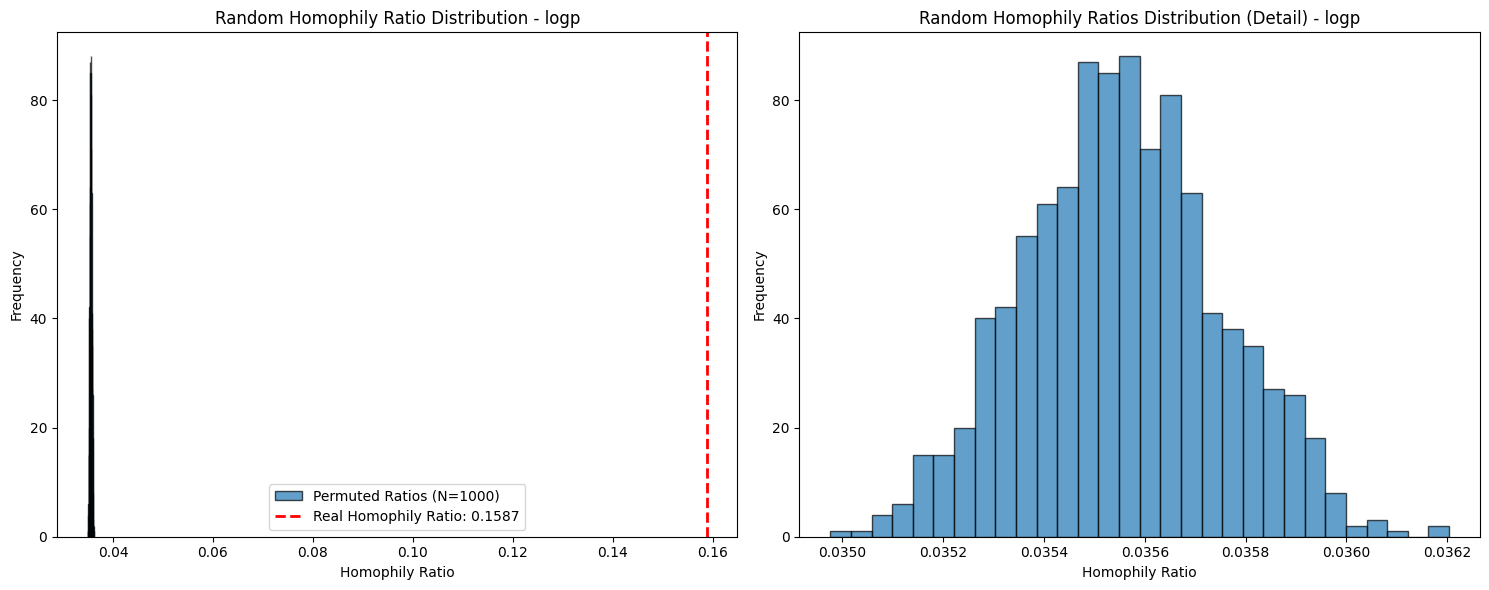

9 0.0 logp


In [13]:
for id in range(0,10): 
    output_dir = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}"
    s = pickle_load(f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}/s.pkl")
    t = pickle_load(f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}/t.pkl")
    smiles = pickle_load(f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}/smiles.pkl")

    date_dict = {smiles: years for smiles, years in zip(df["SMILES"], df["DATE"])}
    mw_dict = {smiles: mw for smiles, mw in zip(df["SMILES"], df["MolecularWeight"])}
    tpsa_dict = {smiles: tpa for smiles, tpa in zip(df["SMILES"], df["TPSA"])}
    logp_dict = {smiles: logp for smiles, logp in zip(df["SMILES"], df["LogP"])}

    tpsa = []
    mw = []
    logp = []
    years = []
    for smile in tqdm(smiles):
        tpsa.append(tpsa_dict[smile])
        mw.append(mw_dict[smile])
        logp.append(logp_dict[smile])
        years.append(int(date_dict[smile]))

    counter_year = collections.Counter(years)
    counter_year_keys = sorted(list(counter_year.keys()))

    count = []
    for key in counter_year_keys:
        count.append(counter_year[key])

    for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:  
        sorted_data = sorted(data)
        sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
        data_label = [0 for _ in range(len(data))]

        label = 0
        index = 0

        for i in count:
            index_next = index + i
            for j in range(index, index_next):
                data_label[sorted_data_index[j]] = label
            index = index_next
            label += 1

        labels = data_label
        labels = np.array(labels)

        lsh_purity_real = lsh_forest_purity(s, t, labels)

        random_purities = []

        for perm in range(num_permutations):
            shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
            random_purity = lsh_forest_purity(s, t, shuffled_labels)
            random_purities.append(random_purity)

        random_purities = np.array(random_purities)
        fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

        axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Permuted Ratios (N={num_permutations})')
        axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, 
                      label=f'Real Homophily Ratio: {lsh_purity_real:.4f}')
        
        axs[0].set_title(f"Random Homophily Ratio Distribution - {label_type}")
        axs[0].set_xlabel("Homophily Ratio")
        axs[0].set_ylabel("Frequency")
        axs[0].legend() 

        axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
        axs[1].set_title(f"Random Homophily Ratios Distribution (Detail) - {label_type}")
        axs[1].set_xlabel("Homophily Ratio")
        axs[1].set_ylabel("Frequency")

        plt.tight_layout() 
        plt.savefig(f"{output_dir}/random_homophily_ratios_{label_type}.png")
        plt.show()

        p_value = np.mean(random_purities >= lsh_purity_real)
        print(id, p_value, label_type)

        scores.append([id, p_value, label_type])

In [7]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
from matplotlib.colors import LinearSegmentedColormap

# ※ pickle_load, lsh_forest_purity, df が定義済みである前提のコードです

scores = []
num_permutations = 1000

for id in range(0, 10): 
    print(f"Processing ID: {id}")
    base_dir = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/{id}"
    output_dir = base_dir
    
    # ディレクトリが存在しない場合の安全策（念のため）
    os.makedirs(output_dir, exist_ok=True)

    try:
        s = pickle_load(f"{base_dir}/s.pkl")
        t = pickle_load(f"{base_dir}/t.pkl")
        x_tm = pickle_load(f"{base_dir}/x.pkl") 
        y_tm = pickle_load(f"{base_dir}/y.pkl")
        smiles = pickle_load(f"{base_dir}/smiles.pkl")
    except FileNotFoundError as e:
        print(f"Skipping ID {id}: File not found - {e}")
        continue

    # 辞書作成 (dfは外部で定義されている前提)
    date_dict = {s: y for s, y in zip(df["SMILES"], df["DATE"])}
    mw_dict = {s: m for s, m in zip(df["SMILES"], df["MolecularWeight"])}
    tpsa_dict = {s: tp for s, tp in zip(df["SMILES"], df["TPSA"])}
    logp_dict = {s: lp for s, lp in zip(df["SMILES"], df["LogP"])}

    tpsa = []
    mw = []
    logp = []
    years = []
    
    # リストの構築
    for smile in smiles:
        tpsa.append(tpsa_dict[smile])
        mw.append(mw_dict[smile])
        logp.append(logp_dict[smile])
        years.append(int(date_dict[smile]))

    # --- カラーマップ準備 (プロット用) ---
    labels_year_full = years
    labels = sorted(list(set(years)))
    num_colors = min(labels)
    total_colors = max(labels) - min(labels) + 1 

    base_cmap = plt.get_cmap("cool")
    colors = [base_cmap(i / total_colors) for i in range(total_colors)]
    
    black_section = [(0, 0, 0, 0)] * num_colors
    new_colors = black_section + colors
    MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

    plot_labels = []   
    plot_nulls = []   
    plot_reals = []   

    # ==========================================
    # 1. Year Full の計算と保存
    # ==========================================
    label_type = "year_full"
    plot_labels.append(label_type)
    
    labels_data = np.array(years)
    purity_real = lsh_forest_purity(s, t, labels_data)
    
    random_purities = []
    for _ in range(num_permutations):
        shuffled = np.random.permutation(labels_data)
        random_purities.append(lsh_forest_purity(s, t, shuffled))
    
    p_value = np.mean(np.array(random_purities) >= purity_real)
    scores.append([id, p_value, label_type])
    plot_nulls.append(random_purities)
    plot_reals.append(purity_real)
    print(f"ID {id}: Purity for '{label_type}': Real={purity_real:.4f}, p-value={p_value:.4f}")

    # ヒストグラム保存
    plt.figure(figsize=(8, 6))
    plt.hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Random (N={num_permutations})')
    plt.axvline(purity_real, color='red', linestyle='dashed', linewidth=2, label=f'Real: {purity_real:.4f}')
    plt.title(f"Homophily Ratio - ID {id} - {label_type}")
    plt.legend()
    plt.savefig(f"{output_dir}/random_homophily_ratios_{label_type}.png")
    plt.close()

    # ★★★ 結果データの保存 (Pickle) ★★★
    result_data = {
        "dataset_id": str(id),
        "feature": label_type,
        "real_hr": purity_real,
        "null_distribution": random_purities,
        "p_value": p_value
    }
    with open(os.path.join(output_dir, f"homophily_data_{label_type}.pkl"), "wb") as f:
        pickle.dump(result_data, f)


    # ==========================================
    # 2. プロパティ (TPSA, MW, LogP) の計算と保存
    # ==========================================
    year_counts = list(collections.Counter(sorted(years)).values())

    for prop_data, prop_name in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:
        plot_labels.append(prop_name)
        
        sorted_indices = np.argsort(prop_data)
        prop_labels = np.zeros(len(prop_data), dtype=int)
        
        current_label = 0
        current_index = 0
        for count in year_counts:
            indices_to_label = sorted_indices[current_index : current_index + count]
            prop_labels[indices_to_label] = current_label
            current_index += count
            current_label += 1 
        
        # 計算
        purity_real = lsh_forest_purity(s, t, prop_labels)
        random_purities = [lsh_forest_purity(s, t, np.random.permutation(prop_labels)) for _ in range(num_permutations)]
        
        p_value = np.mean(np.array(random_purities) >= purity_real)
        scores.append([id, p_value, prop_name])
        plot_nulls.append(random_purities)
        plot_reals.append(purity_real)
        print(f"ID {id}: Homophily for '{prop_name}': Real={purity_real:.4f}, p-value={p_value:.4f}")

        # ヒストグラム保存
        plt.figure(figsize=(8, 6))
        plt.hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Random (N={num_permutations})')
        plt.axvline(purity_real, color='red', linestyle='dashed', linewidth=2, label=f'Real: {purity_real:.4f}')
        plt.title(f"Homophily Ratio - ID {id} - {prop_name}")
        plt.legend()
        plt.savefig(f"{output_dir}/random_homophily_ratios_{prop_name}.png")
        plt.close()

        # ★★★ 結果データの保存 (Pickle) ★★★
        result_data = {
            "dataset_id": str(id),
            "feature": prop_name,
            "real_hr": purity_real,
            "null_distribution": random_purities,
            "p_value": p_value
        }
        with open(os.path.join(output_dir, f"homophily_data_{prop_name}.pkl"), "wb") as f:
            pickle.dump(result_data, f)

    # ==========================================
    # 3. Boxplot の作成
    # ==========================================
    # ※ 先ほど議論した「軸省略 (Broken Axis)」を行いたい場合は、
    #    ここのブロックを前回の回答の描画コードに差し替えてください。
    #    現在は元のコードのままです。
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    bp = ax.boxplot(
        plot_nulls,
        labels=plot_labels,
        patch_artist=True,
        widths=0.4,
        showfliers=True,
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, 
                        linestyle='none', markeredgecolor='none', alpha=0.6)
    )

    for patch in bp['boxes']:
        patch.set_facecolor('#D3D3D3')
        patch.set_edgecolor('#555555')
        patch.set_linewidth(1)
    
    for element in ['whiskers', 'caps']:
        plt.setp(bp[element], color='#555555', linewidth=1)
    
    plt.setp(bp['medians'], color='black', linewidth=1.5)

    for idx, real_val in enumerate(plot_reals):
        ax.scatter(
            idx + 1, 
            real_val, 
            color='#4169E1',
            s=180, 
            edgecolor='black', 
            linewidth=1.2,
            zorder=10, 
            label="Real Value" if idx == 0 else None
        )

    ax.set_title(f"Homophily Ratio: Observed vs Random Distributions (ID: {id})", fontsize=16, pad=15)
    ax.set_ylabel("Homophily Ratio", fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='lightgray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/homophily_boxplot_style_ID{id}.png")
    plt.close()

print("All IDs processed.")

Processing ID: 0
ID 0: Purity for 'year_full': Real=0.3304, p-value=0.0000
ID 0: Homophily for 'tpsa': Real=0.2614, p-value=0.0000
ID 0: Homophily for 'mw': Real=0.1718, p-value=0.0000
ID 0: Homophily for 'logp': Real=0.1582, p-value=0.0000


/tmp/ipykernel_486178/1093322965.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Processing ID: 1
ID 1: Purity for 'year_full': Real=0.3302, p-value=0.0000
ID 1: Homophily for 'tpsa': Real=0.2624, p-value=0.0000
ID 1: Homophily for 'mw': Real=0.1721, p-value=0.0000
ID 1: Homophily for 'logp': Real=0.1582, p-value=0.0000


/tmp/ipykernel_486178/1093322965.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Processing ID: 2
ID 2: Purity for 'year_full': Real=0.3303, p-value=0.0000
ID 2: Homophily for 'tpsa': Real=0.2624, p-value=0.0000
ID 2: Homophily for 'mw': Real=0.1729, p-value=0.0000
ID 2: Homophily for 'logp': Real=0.1591, p-value=0.0000


...

/tmp/ipykernel_486178/1093322965.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Processing ID: 8
ID 8: Purity for 'year_full': Real=0.3296, p-value=0.0000
ID 8: Homophily for 'tpsa': Real=0.2633, p-value=0.0000
ID 8: Homophily for 'mw': Real=0.1723, p-value=0.0000
ID 8: Homophily for 'logp': Real=0.1583, p-value=0.0000


/tmp/ipykernel_486178/1093322965.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Processing ID: 9
ID 9: Purity for 'year_full': Real=0.3294, p-value=0.0000
ID 9: Homophily for 'tpsa': Real=0.2624, p-value=0.0000
ID 9: Homophily for 'mw': Real=0.1726, p-value=0.0000
ID 9: Homophily for 'logp': Real=0.1587, p-value=0.0000
All IDs processed.


/tmp/ipykernel_486178/1093322965.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


In [ ]:
df_scores = pd.read_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/scores.csv", names=["ID", "P-value", "Label Type"])
scores_new = pd.DataFrame(scores, columns=["ID", "P-value", "Label Type"])
df_combined = pd.concat([df_scores, scores_new], ignore_index=True)
df_combined.to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/scores.csv", index=False)

# all surechembl → memory error

In [ ]:
input_file = "../../data/processed/surechembl/250106_sorted.tsv"
output_ecfp = "../../data/processed/surechembl/surechembl_ecfp.pickle"
output_mol = "../../data/processed/surechembl/surechembl_mol.pickle"
output_year = "../../data/processed/surechembl/surechembl_year.pickle"

with open(input_file, "r") as f:
    lines = f.readlines()

total_lines = len(lines)

with open(input_file, "r") as f, open(output_ecfp, "ab") as pkl_out_ecfp, open(output_year, "ab") as pkl_out_year, open(pkl_out_smiles, "ab") as pkl_out_smiles:
    for line in tqdm(lines, total=total_lines, desc="Processing SMILES"):
        try:
            smiles = line.split("\t")[0]
            year = int(line.split("\t")[1].split("-")[0])
        except ValueError:
            print(f"Skipping line due to ValueError: {line.strip()}")
            continue
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            ecfp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
            pickle.dump(ecfp, pkl_out_ecfp, protocol=pickle.HIGHEST_PROTOCOL)
            pickle.dump(smiles, pkl_out_smiles, protocol=pickle.HIGHEST_PROTOCOL)
            pickle.dump(year, pkl_out_year, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
output_ecfp = "../../data/processed/surechembl/surechemble_ecfps.pickle"
output_smiles = "../../data/processed/surechembl/surechemble_smiles.pickle"
output_year = "../../data/processed/surechembl/surechemble_years.pickle"

smiles = pickle_load(output_smiles)
year = pickle_load(output_year)
ecfp = pickle_load(output_ecfp)

In [ ]:
print(len(smiles), len(year), len(ecfp))

23389481 23389481 23389481


In [ ]:
print(smiles[0])
print(year[0])
print(ecfp[0])

OC1=C2C=CC=CC2=CC2=CC3=C(CC=CC3)C=C12
1962


In [ ]:
from tqdm import tqdm

def ecfp_to_set(fp):
    return set(fp.GetOnBits())

ecfp_sets = []
for e, y, s in zip(ecfp, year, smiles):
    ecfp_sets.append((ecfp_to_set(e), y, s))

Converting ECFP to set:   0%|          | 75631/23389481 [10:14<52:37:24, 123.06it/s]


In [ ]:
print(len(ecfp_sets))

23389481


In [ ]:
pickle_dump(ecfp_sets, "../../data/processed/surechembl/surechembl_ecfp_sets.pkl")

In [ ]:
ecfp_sets = pickle_load("../../data/processed/surechembl/surechembl_ecfp_sets.pkl")

In [ ]:
from datasketch import MinHash, LeanMinHash

def create_lean_minhash(set_data, num_perm=64):
    m = MinHash(num_perm=num_perm)
    for item in set_data:
        m.update(str(item).encode('utf8'))
    return LeanMinHash(m) 

In [ ]:
import pickle
from tqdm import tqdm

output_path = "../../data/processed/surechembl/minhash_list.pkl"

with open(output_path, "ab") as f:
    for data in tqdm(ecfp_sets):
        e, y, s = data[0], data[1], data[2]
        mh = create_lean_minhash(e)
        new_data = (mh, y, s)
        pickle.dump(new_data, f)

100%|██████████| 23389481/23389481 [8:40:25<00:00, 749.06it/s]   


In [ ]:
import pickle
from datasketch import LeanMinHash
from tqdm import tqdm

def minhash_to_vector(minhash):
    return list(minhash.digest())

input_path = "../../data/processed/surechembl/minhash_list.pkl" 
output_path = "../../data/processed/surechembl/minhash_vectors.pkl" 

k = 0
with open(input_path, "rb") as fin, open(output_path, "wb") as fout:
    while True:
        try:
            data = pickle.load(fin) 
            mh = data[0] 
            y = data[1]  
            s = data[2]  
            vec = minhash_to_vector(mh) 
            new_data = (vec, y, s)
            pickle.dump(new_data, fout) 
        except EOFError:
            k += 1
            break

In [ ]:
from tqdm.auto import trange
enc = tm.Minhash(64)
lf = tm.LSHForest(64)

d = 64
n = 23320261

data = []
input_path = "../../data/processed/surechembl/minhash_vectors.pkl" 

with open(input_path, "rb") as f:
    for _ in trange(n):
        try:
            vec = pickle.load(f)
            converted_vec = [np.uint8(x) for x in vec[0]]
            data.append(converted_vec)
        except EOFError:
            break

data = enc.batch_from_binary_array(data)
lf.batch_add(data)
lf.index()

In [ ]:
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)

In [ ]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

In [ ]:
output_dir = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/surechembl/whole"

In [ ]:
os.makedirs(output_dir, exist_ok=True)

In [ ]:
filepaths = {
    "x": f"{output_dir}/x.pkl",
    "y": f"{output_dir}/y.pkl",
    "s": f"{output_dir}/s.pkl",
    "t": f"{output_dir}/t.pkl",
}

In [ ]:
pickle_dump(list(x), filepaths["x"])
pickle_dump(list(y), filepaths["y"])
pickle_dump(list(s), filepaths["s"])
pickle_dump(list(t), filepaths["t"])

# visualize surechembl's compound

In [ ]:
dir_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/surechembl/0/"

smiles_path = os.path.join(dir_path, "smiles.pkl")
years_path = os.path.join(dir_path, "years.pkl")

x_path = os.path.join(dir_path, "x.pkl")
y_path = os.path.join(dir_path, "y.pkl")
s_path = os.path.join(dir_path, "s.pkl")
t_path = os.path.join(dir_path, "t.pkl")

In [ ]:
years = pickle_load(years_path)
smiles = pickle_load(smiles_path)
x = pickle_load(x_path)
y = pickle_load(y_path)
s = pickle_load(s_path)
t = pickle_load(t_path)

In [ ]:
print(len(years), len(smiles), len(x), len(y), len(s), len(t))

996720 996720 996720 996720 996717 996717


In [ ]:
# target_smiles = "CON=C(C(=O)NC1[C@@H]2SCC(CSC3=NN=NN3C)=C(N2C1=O)C(O)=O)C1=CC(NC=O)=NC=C1"
# target_smiles = "C[C@H]1NC2=NN(C)C(=O)C3=C2C=C(C(=O)N3CCCCCC2CC(C2)CCC(F)(F)C2=C(F)C1=CC=C2)C1(CC1)C#N"

target_smiles = "CC1=CC=C2C(OC3=C2C=CC(=C3)C#N)=C1C1=[N+](C)C=C(C)C(C)=C1"

# target_kannnoki = "C\#"

for i in range(len(smiles)):
    if smiles[i] == target_smiles:
        index = i
print(index)

410878


In [ ]:
neighbors_1 = []
for i in range(len(s)):
    if s[i] == index:
        neighbors_1.append(t[i])
    if t[i] == index:
        neighbors_1.append(s[i])
neighbors_1 = list(set(neighbors_1))
print(neighbors_1)

[645665, 969191, 122399]


In [ ]:
neighbors_2 = []
for i in range(len(s)):
    if s[i] in neighbors_1:
        neighbors_2.append(t[i])
    if t[i] in neighbors_1:
        neighbors_2.append(s[i])
neighbors_2 = list(set(neighbors_2))
print(neighbors_2)

[915912, 983680, 410878, 472071]


In [ ]:
neighbors_3 = []
for i in range(len(s)):
    if s[i] in neighbors_2:
        neighbors_3.append(t[i])
    if t[i] in neighbors_2:
        neighbors_3.append(s[i])
neighbors_3 = list(set(neighbors_3))
print(neighbors_3)

[645665, 345122, 164451, 812547, 969191, 385528, 607422, 122399]


In [ ]:
neighbors_4 = []
for i in range(len(s)):
    if s[i] in neighbors_3:
        neighbors_4.append(t[i])
    if t[i] in neighbors_3:
        neighbors_4.append(s[i])
neighbors_4 = list(set(neighbors_4))
print(neighbors_4)

[983680, 453665, 826786, 333057, 766884, 472071, 915912, 172427, 529804, 613940, 248345, 410878]


In [ ]:
neighbors_5 = []
for i in range(len(s)):
    if s[i] in neighbors_4:
        neighbors_5.append(t[i])
    if t[i] in neighbors_4:
        neighbors_5.append(s[i])
neighbors_5 = list(set(neighbors_5))
print(neighbors_5)

neighbors_6 = []
for i in range(len(s)):
    if s[i] in neighbors_5:
        neighbors_6.append(t[i])
    if t[i] in neighbors_5:
        neighbors_6.append(s[i])
neighbors_6 = list(set(neighbors_6))
print(neighbors_6)

[492608, 645665, 345122, 164451, 812547, 969191, 833451, 795149, 474989, 848816, 727250, 390195, 28150, 385528, 97053, 607422, 122399]
[879744, 333057, 983680, 472071, 172427, 529804, 248345, 453665, 160801, 826786, 766884, 510763, 363058, 613940, 774976, 767431, 915912, 143689, 455762, 209121, 252262, 529894, 410878]


In [ ]:
neighbors_smiles = []
for i in range(len(smiles)):
    if i in neighbors_1 or i in neighbors_2 or i in neighbors_3 or i in neighbors_4 or i in neighbors_5 or i in neighbors_6:
        neighbors_smiles.append(smiles[i])

In [ ]:
neighbors_years = []
for i in range(len(years)):
    if i in neighbors_1 or i in neighbors_2 or i in neighbors_3 or i in neighbors_4 or i in neighbors_5 or i in neighbors_6:
        neighbors_years.append(str(years[i]))

In [ ]:
print(len(neighbors_smiles), len(neighbors_years))

40 40


In [ ]:
from rdkit.Chem import Draw

options = Draw.MolDrawOptions()
options.legendFontSize = 40   # default: 16
options.legendFraction = 0.2   # default: 0.1

mols = [Chem.MolFromSmiles(smiles) for smiles in neighbors_smiles]

grid_img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,  
    subImgSize=(400, 400),
    drawOptions=options, 
    legends=neighbors_years,
)

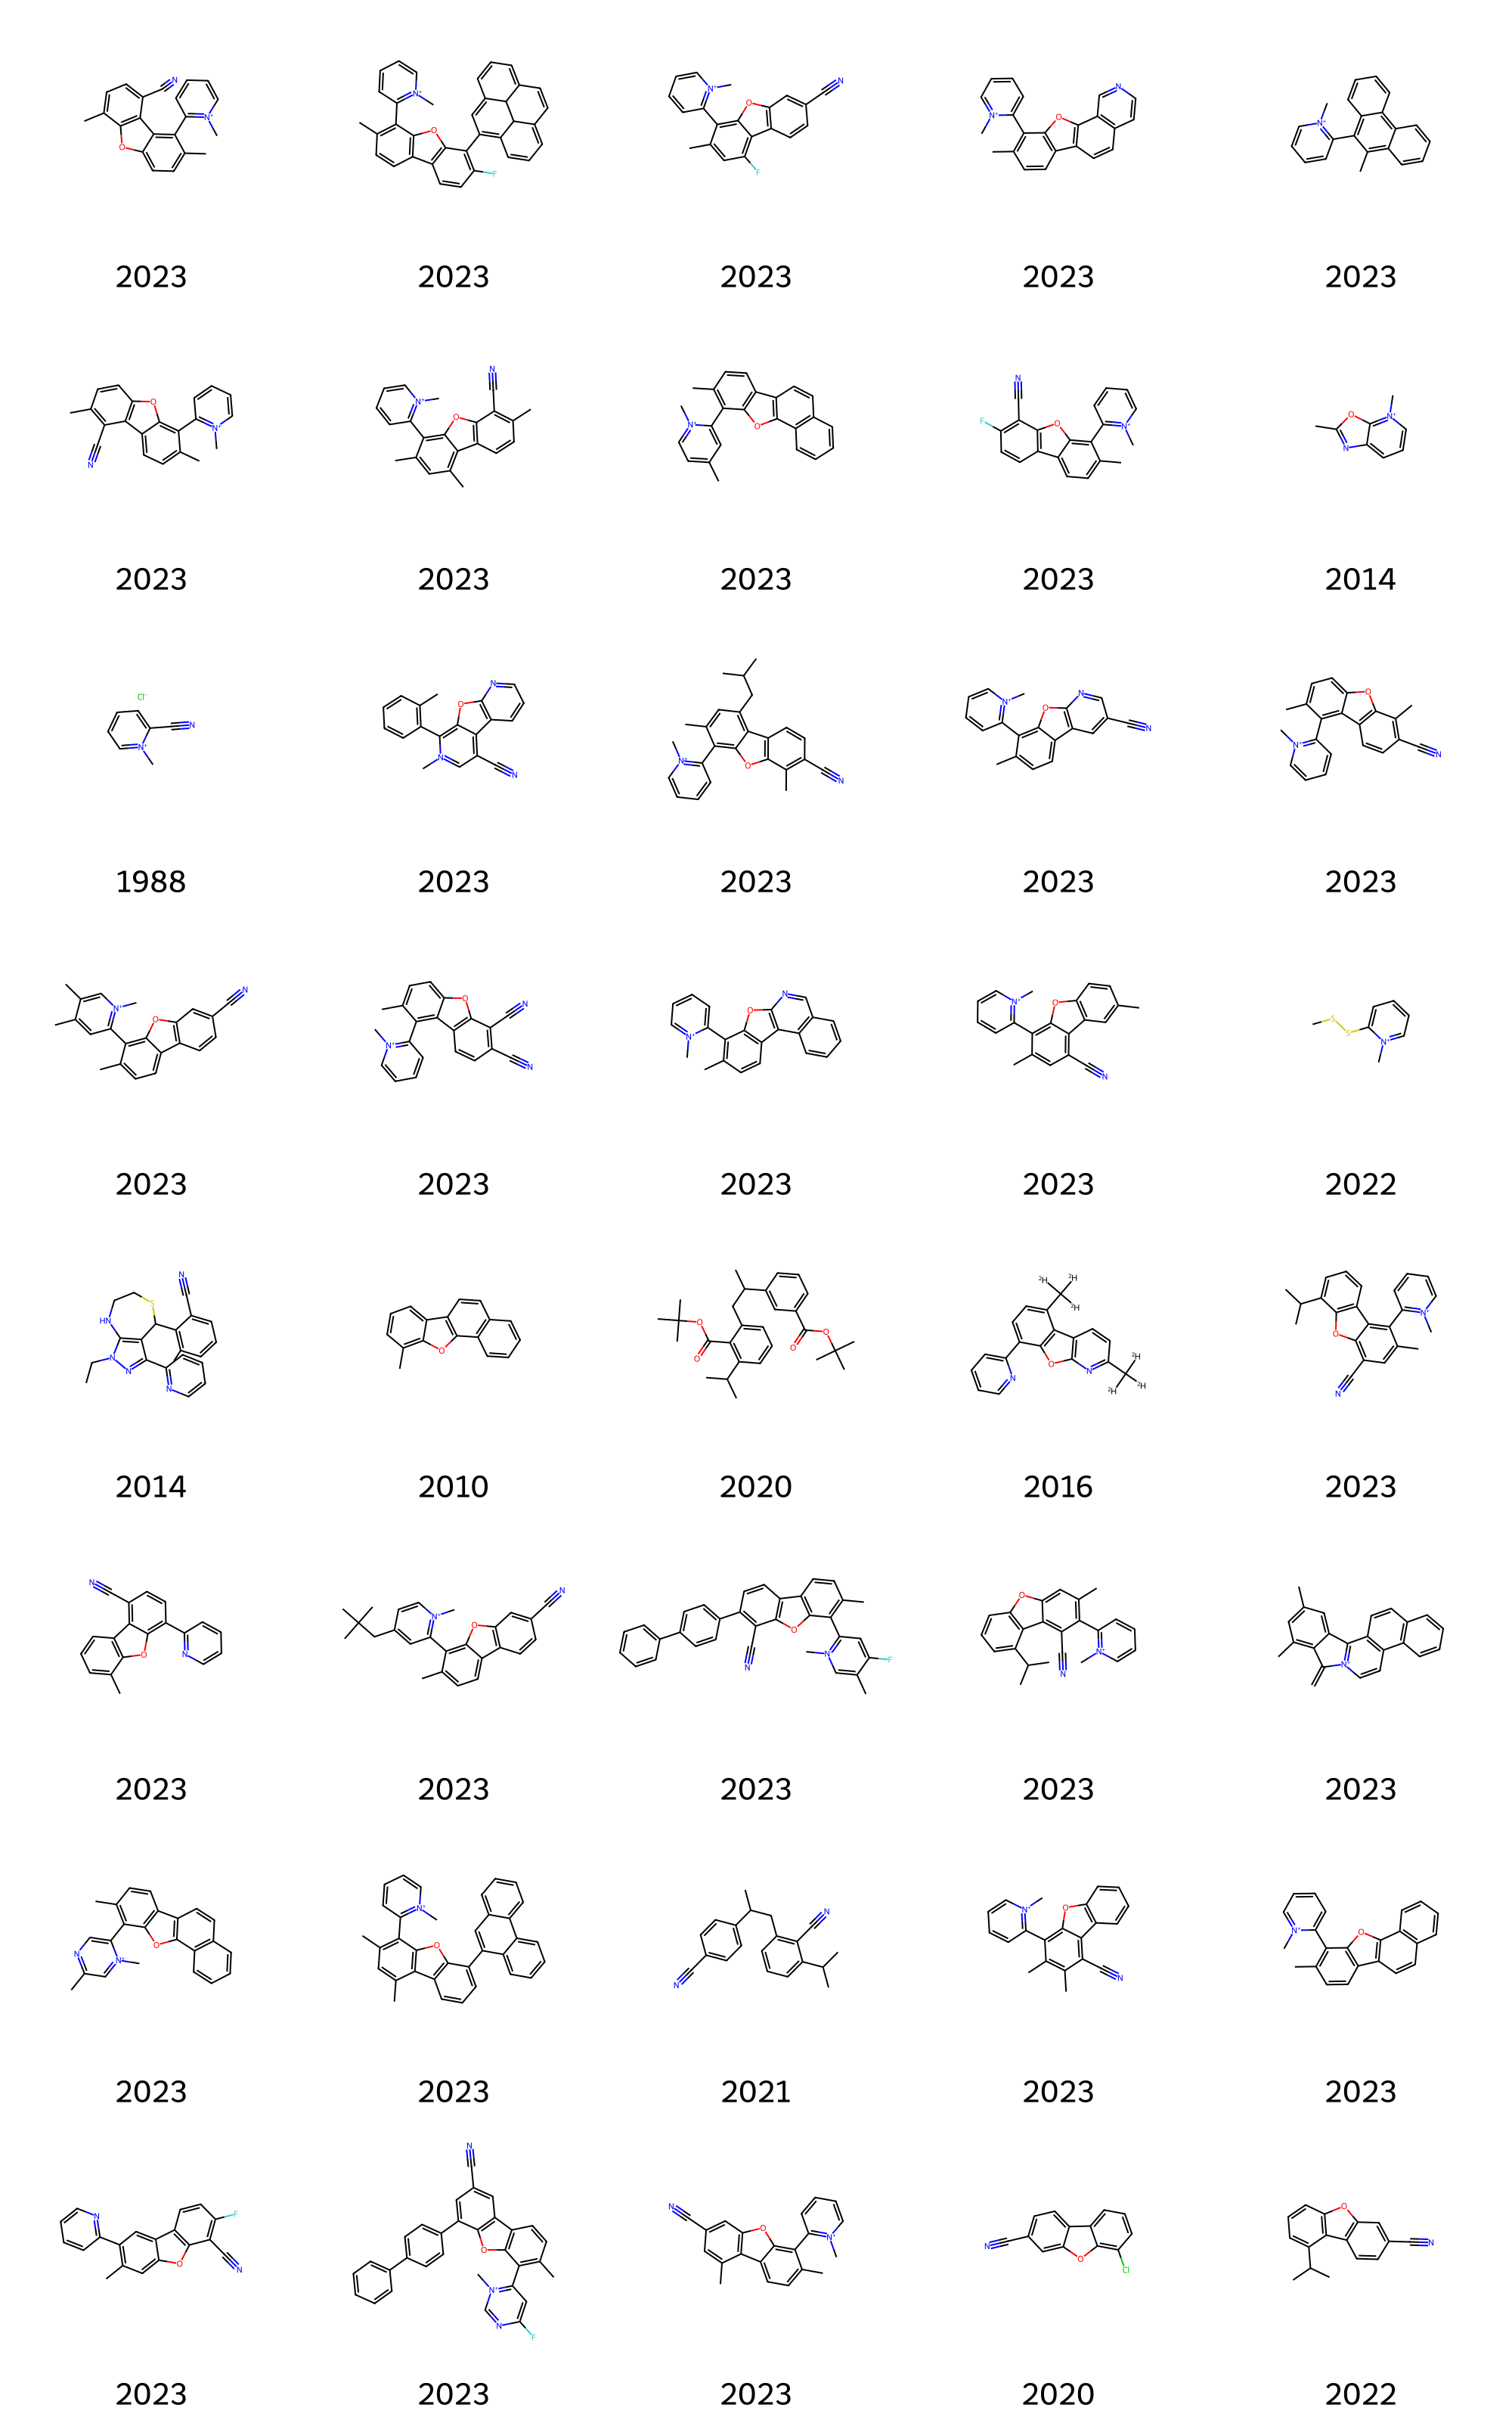

In [ ]:
grid_img